In [21]:
#### Final Project - Mohan Kumar Paramasivan - Dataset 2 ####
#### The Oxford Parkinson’s Disease Detection Dataset ####
#### Algorithm 1 - Neural Networks ####

np.set_printoptions(precision=5, suppress=True, floatmode='fixed')

#### Sigmoid Function ####
def sigmoid(z):
    return (1 / (1 + np.exp(-z)))

#### Forward Propagation Function ####
def forward_propagation(x, y, Thetas, instance_num, verbose=False):
    if verbose: print(f"\tProcessing training instance {instance_num}")
    if verbose: print(f"\tForward propagating the input {x}")

    a = np.concatenate(([1.0], x))
    neuron = [a]
    if verbose: print(f"a1:", a)
    
    for i, Theta in enumerate(Thetas):
        z = Theta @ a
        if verbose: print(f"z{i+2}:", z)
        a = sigmoid(z)
        if i < len(Thetas) - 1:
            a = np.concatenate(([1.0], a))
        if verbose: print(f"a{i+2}:", a)
        neuron.append(a)

    fx = neuron[-1]
    J = float(np.sum((-y * np.log(fx)) - ((1-y) * np.log(1-fx))))

    ##print(f"a{i+2}:", a)
    if verbose: print("f(x):", neuron[-1])
    if verbose: print(f"Predicted output for instance {instance_num}:", neuron[-1])
    if verbose: print(f"Expected output for instance {instance_num}:", y)
    if verbose: print(f"Cost, J, associated with instance {instance_num}: {round(J, 3)}\n")
    return neuron, J        

#### Cost Function ####
def cost_function(J_list, Thetas, lambda_, verbose=False):
    n = len(J_list)
    reg = (lambda_/(2 * n)) * sum(np.sum(Theta[:, 1:] ** 2) for Theta in Thetas)
    J_final = (sum(J_list)/n) + reg
    if verbose: print(f"Final (regularized) cost, J, based on the complete training set:{round(J_final, 5)}")
    return J_final 

#### Back Propagation function ####
def back_propagation(neuron, y, Thetas, instance_num, verbose=False):

    deltas = []
    gradients = []

    if verbose: print(f"Computing gradients based on training instance {instance_num}:")
    fx = neuron[-1]
    delta_output = fx - y
    deltas.append(delta_output)
    if verbose: print(f'Delta{len(neuron)}:', delta_output)       
 
    for i in range(len(Thetas) - 1, 0, -1):
        propagate = Thetas[i].T @ deltas[-1]
        propagate_no_bias = propagate[1:]
        a = neuron[i][1:]
        delta_hidden = propagate_no_bias * a * (1 - a)
        deltas.append(delta_hidden)
        if verbose: print(f'Delta{i+1}:', delta_hidden)
    deltas.reverse()

    # Gradients
    for i in range(len(Thetas)):
        grad = np.outer(deltas[i], neuron[i])
        gradients.append(grad)
        if verbose: print(f'Gradients of Theta{i+1} based on training instance {instance_num}:\n', grad)

    return gradients


#### Regularized Gradients Function ####
def regularized_gradients(all_instance_gradients, Thetas, lambda_, verbose=False):
    n = len(all_instance_gradients)
    Final_Gradients = []
    
    for i in range(len(Thetas)):
        # Sum gradients across all instances
        total_grad = sum(grads[i] for grads in all_instance_gradients)
        
        # Build regularization matrix (skip bias column)
        reg = np.zeros_like(Thetas[i])
        reg[:, 1:] = Thetas[i][:, 1:]
        
        # Average + regularize
        final_grad = (total_grad / n) + (lambda_ / n) * reg
        Final_Gradients.append(final_grad)
        if verbose: print(f'Final regularized gradients of Theta{i+1}:\n', final_grad)
    
    return Final_Gradients

In [25]:
#### Final Project - Mohan Kumar Paramasivan - Dataset 2 ####
#### The Oxford Parkinson’s Disease Detection Dataset ####
#### Algorithm 1 - Neural Networks ####


def adjust_all_weights(Thetas, Final_Gradients, alpha, verbose=False):
    adjusted_Thetas = []
    for i in range(len(Thetas)):
        new_Theta = Thetas[i] - alpha * Final_Gradients[i]
        adjusted_Thetas.append(new_Theta)
        if verbose: print(f'Updated Theta{i+1}:\n', new_Theta)
    return adjusted_Thetas

In [27]:
#### Final Project - Mohan Kumar Paramasivan - Dataset 2 ####
#### The Oxford Parkinson’s Disease Detection Dataset ####
#### Algorithm 1 - Neural Networks ####

def train(X, Y, Thetas, alpha, lambda_, m=1000):
    for iteration in range(m):
        all_instance_gradients = []
        J_list = []
        all_neurons = []
        
        for i, (x, y) in enumerate(zip(X, Y)):
            result, J = forward_propagation(x, y, Thetas, i+1, verbose=False)
            J_list.append(float(J))
            all_neurons.append(result)
        
        current_J = cost_function(J_list, Thetas, lambda_, verbose=False)
        
        for i, (x, y) in enumerate(zip(X, Y)):
            grads = back_propagation(all_neurons[i], y, Thetas, i+1, verbose=False)
            all_instance_gradients.append(grads)
        
        Final_Gradients = regularized_gradients(all_instance_gradients, Thetas, lambda_, verbose=False)
        Thetas = adjust_all_weights(Thetas, Final_Gradients, alpha, verbose=False)

        if (iteration + 1) % 1000 == 0:
            print(f'Iteration {iteration+1}: J = {current_J:.6f}')
    
    return Thetas

In [29]:
#### Final Project - Mohan Kumar Paramasivan - Dataset 2 ####
#### The Oxford Parkinson’s Disease Detection Dataset ####
#### Algorithm 1 - Neural Networks ####

#### Normalize function used to normalize the data for each columns between 0 and 1
def normalize(X_train, X_test):
    #### pick the minimum value from each column and assign as X_Min. axis = 0 means pick min value from each columns
    X_Min = X_train.min(axis = 0) 
    #### pick the maximum value from each column and assign as X_Max. axis = 0 means pick max value from each columns
    X_Max = X_train.max(axis = 0)
    #### The difference between X_Max and X_Min is used as the denominator for the normalize formula calculation
    denominator = (X_Max - X_Min)
    #### To avoid dividing by zero, replace 0 values in the denominator with 1
    denominator[denominator == 0] = 1 
    #### Each value in the column is normalized with the Normalization formula : (X - X_Min) / (X_Max - X_Min)
    X_train_norm = ((X_train - X_Min) / denominator)
    #### The testing dataset is normalized using the training dataset
    X_test_norm = ((X_test - X_Min) / denominator)
    return X_train_norm, X_test_norm
    #### returns the normalized value for the training and test set

In [31]:
#### Final Project - Mohan Kumar Paramasivan - Dataset 2 ####
#### The Oxford Parkinson’s Disease Detection Dataset ####
#### Algorithm 1 - Neural Networks ####

#### Added in HW 3 ####
def create_stratified_folds(X, y, k=10):

    labels = np.unique(y)
    #### np.unique(y) - returns the unique labels from the dataset
    #### get all unique class labels e.g. for WDBC dataset it returns ['Benign', 'Malignant']

    folds = [[] for i in range(k)]
    #### create k empty lists e.g. [[], [], [], [], []]

    for label in labels:
        #### handle each label values separately to keep proportions

        label_indices = np.where(y == label)[0]
        #### y == label compares every value in y with the label value and returns True/False for every value of y             
        #### np.where finds positions where condition is True and returns a tuple containing a numpy array e.g. (array([0, 2, 3]),)
        #### [0] returns the numpy array from the tuple e.g. array([0, 2, 3])

        np.random.shuffle(label_indices)
        #### np.random.shuffle(label_indices) randomly shuffles the order of the values in the label_indices array
        #### the original array values will be randomly reshuffled and presented in a different order in the array
        #### array([1,2,3,4]) will be reshuffled to array([3,2,4,1])


        for i, index in enumerate(label_indices):
        #### enumerate returns both the position number (i) and label_indices values (index)
        #### i = position number e.g. 0, 1, 2, 3, 4,...
        #### index = row numbers in label indices values e.g. 3, 2, 4, 1, ...
            folds[i % k].append(index)
            #### i % k provides the remainder values of dividing the position number with k = 5 (no of folds) e.g (i % k) is 0, 1, 2, 3, 4
            #### folds[i % k] assigns each remainder values to each different folds e.g fold 0, fold 1, fold 2, fold 3, fold 4
            #### folds[i % k].append(index) adds the row numbers from label indices to each fold

    #### returns k folds as a list of k lists ####
    #### each fold contains row numbers of instances assigned to that fold
    return folds

In [33]:
#### Final Project - Mohan Kumar Paramasivan - Dataset 2 ####
#### The Oxford Parkinson’s Disease Detection Dataset ####
#### Algorithm 1 - Neural Networks ####

#### Added in HW 3 ####
def accuracy(y_true, y_pred):
    y_true = list(y_true)
    y_pred = list(y_pred)
    correct = sum(yt == yp for yt, yp in zip(y_true, y_pred))
    return correct / len(y_true)

def precision(y_true, y_pred, positive_class = 1):

    True_Positive  = 0
    False_Positive = 0

    for ytrue, ypred in zip(y_true, y_pred):
        #### zip() pairs each item from y_true and y_pred ####
        #### for loop iterates through each pair of ytrue and ypred ####
        if ytrue == positive_class and ypred == positive_class:
            True_Positive += 1   
            #### Predicted positive and Actual positive ####
        elif ytrue != positive_class and ypred == positive_class:
            False_Positive += 1  
            #### Predicted positive but Actual negative ####

    if True_Positive + False_Positive == 0:
        #### returns 0 when divided by 0 ####
        return 0.0

    #### precision = True Positive / (True Positive + False Positive) ####
    return True_Positive / (True_Positive + False_Positive)

def recall(y_true, y_pred, positive_class = 1):

    True_Positive  = 0
    False_Negative = 0

    for ytrue, ypred in zip(y_true, y_pred):
        #### zip() pairs each item from y_true and y_pred ####
        #### for loop iterates through each pair of ytrue and ypred ####
        if ytrue == positive_class and ypred == positive_class:
            True_Positive += 1   
            #### Predicted positive and Actual positive ####
        elif ytrue == positive_class and ypred != positive_class:
            False_Negative += 1  
            #### Predicted negative but Actual positive ####

    if True_Positive + False_Negative == 0:
        #### returns 0 when divided by 0 ####
        return 0.0
        
    #### recall = True Positive / (True Positive + False Negative) ####
    return True_Positive / (True_Positive + False_Negative)

def f1_score(y_true, y_pred, positive_class = 1):

    prec = precision(y_true, y_pred, positive_class)
    rec = recall(y_true, y_pred, positive_class)

    if prec + rec == 0:
        #### returns 0 when divided by 0 ####
        return 0.0
        
    #### F1 = 2 * (precision * recall) / (precision + recall) ####  
    return 2 * (prec * rec) / (prec + rec)

In [35]:
#### Final Project - Mohan Kumar Paramasivan - Dataset 2 ####
#### The Oxford Parkinson’s Disease Detection Dataset ####
#### Algorithm 1 - Neural Networks ####

def initialize_weights(layer_sizes):
    Thetas = []
    for i in range(len(layer_sizes) - 1):
        Theta = np.random.uniform(-1, 1, (layer_sizes[i+1], layer_sizes[i]+1))  
        #### random.uniform(minimum value, maximum value, shape of the array(rows, columns)
        #### generates random values between -1 and 1
        #### rows = layer_sizes[i+1] : number of neurons in next layer
        #### cols = layer_sizes[i]+1 : number of neurons in current layer + 1 bias
        Thetas.append(Theta)
    return Thetas    

In [37]:
#### Final Project - Mohan Kumar Paramasivan - Dataset 2 ####
#### The Oxford Parkinson’s Disease Detection Dataset ####
#### Algorithm 1 - Neural Networks ####

def predict(X, Thetas):
    y_pred = [] ### initialize with empty list
    for x in X:
        neuron, _ = forward_propagation(x, np.array([0.0]), Thetas,0)
        ## Cost function J is ignored
        ## dummy value np.array([0.0]) is used for Y for the forward propagation function
        ## dummy value 0 is used for instance_num for the forward propagation function
        y_pred.append(1 if neuron[-1] >= 0.5 else 0)
    return np.array(y_pred)

In [39]:
#### Final Project - Mohan Kumar Paramasivan - Dataset 2 ####
#### The Oxford Parkinson’s Disease Detection Dataset ####
#### Algorithm 1 - Neural Networks ####

def cross_validate_nn(X, y, layer_sizes, alpha, lambda_, m=1000, k=10):
    
    folds = create_stratified_folds(X, y, k)
    #### creates k = 10 stratified folds of the dataset ####
    
    accuracy_scores = []
    f1_scores = []
    #### initial empty list created for accuracy_scores, precision_scores, recall_scores, f1_scores ####

    for i in range(k):
        #### the for loop iterates for each fold ####
        
        test_indices  = np.array(folds[i])
        #### the selected fold is choosen as the test indices ####
        #### the values in the folds are converted in to numpy array ####
        
        train_indices = np.array([idx for j in range(k) if j != i for idx in folds[j]])
        #### for j in range(k) for j != i : it picks the rest of the folds other than the test fold for training indices ####
        #### the values in the folds are converted in to numpy array ####
        
        X_train, y_train = X[train_indices], y[train_indices]
        #### divides the training indices into X_train and y_train ####
        X_test,  y_test  = X[test_indices],  y[test_indices]
        #### divides the testing indices into X_test and y_test ####
        
        X_train, X_test = normalize(X_train, X_test)
        #### normalize the training and testing instances ####
        
        Thetas = initialize_weights(layer_sizes)
        #### assigns random weights to the layers ####
        Thetas = train(X_train, y_train, Thetas, alpha, lambda_, m)
        #### Updates the Thetas based on the interation and reduces the cost function ####
        y_pred = predict(X_test, Thetas)
        #### Predicts the output ####
        
        accuracy_scores.append(accuracy(y_test, y_pred))
        f1_scores.append(f1_score(y_test, y_pred))
        #### calculates and stores metrics for kth fold ####
        
    return {
        'Accuracy': round(float(np.mean(accuracy_scores)), 6),
        'F1 Score': round(float(np.mean(f1_scores)), 6)
    }

In [202]:
#### Final Project - Mohan Kumar Paramasivan - Dataset 2 ####
#### The Oxford Parkinson’s Disease Detection Dataset ####
#### Algorithm 1 - Neural Networks ####

#### Parkinsons Disease Dataset ####
import pandas as pd
import numpy as np
Parkinsons_disease_dataset = pd.read_csv("C:/Users/mohan/OneDrive/Desktop/UMass Amhers MSCS/Spring 2026 - Machine Learning/Final Project/Final_Project_CMPSCI_589_Spring2026_Supporting_Files/Final_Project_CMPSCI_589_Spring2026_Supporting_Files/parkinsons.csv", header=0)
Parkinsons_disease_dataset = Parkinsons_disease_dataset.dropna()

X_Parkinsons = np.array(Parkinsons_disease_dataset.drop('Diagnosis', axis=1), dtype=float)
Y_Parkinsons = np.array(Parkinsons_disease_dataset['Diagnosis'], dtype=float)

print('Parkinsons Disease shape:', X_Parkinsons.shape, Y_Parkinsons.shape)
print('Number of features:', X_Parkinsons.shape[1])
Parkinsons_disease_dataset.head()

Parkinsons Disease shape: (195, 22) (195,)
Number of features: 22


,MDVP:Fo(Hz),MDVP:Fhi(Hz),MDVP:Flo(Hz),MDVP:Jitter(%),MDVP:Jitter(Abs),MDVP:RAP,MDVP:PPQ,Jitter:DDP,MDVP:Shimmer,MDVP:Shimmer(dB),...,Shimmer:DDA,NHR,HNR,RPDE,DFA,spread1,spread2,D2,PPE,Diagnosis
0,119.992,157.302,74.997,0.00784,0.00007,0.00370,0.00554,0.01109,0.04374,0.426,...,0.06545,0.02211,21.033,0.414783,0.815285,-4.813031,0.266482,2.301442,0.284654,1
1,122.400,148.650,113.819,0.00968,0.00008,0.00465,0.00696,0.01394,0.06134,0.626,...,0.09403,0.01929,19.085,0.458359,0.819521,-4.075192,0.335590,2.486855,0.368674,1
2,116.682,131.111,111.555,0.01050,0.00009,0.00544,0.00781,0.01633,0.05233,0.482,...,0.08270,0.01309,20.651,0.429895,0.825288,-4.443179,0.311173,2.342259,0.332634,1
3,116.676,137.871,111.366,0.00997,0.00009,0.00502,0.00698,0.01505,0.05492,0.517,...,0.08771,0.01353,20.644,0.434969,0.819235,-4.117501,0.334147,2.405554,0.368975,1
4,116.014,141.781,110.655,0.01284,0.00011,0.00655,0.00908,0.01966,0.06425,0.584,...,0.10470,0.01767,19.649,0.417356,0.823484,-3.747787,0.234513,2.332180,0.410335,1


In [45]:
#### Final Project - Mohan Kumar Paramasivan - Dataset 2 ####
#### The Oxford Parkinson’s Disease Detection Dataset ####
#### Algorithm 1 - Neural Networks ####

lambdas = [0, 0.1, 0.01]
architectures = [
    [22, 2, 1],           #### one hidden layer, simple network
    [22, 16, 1],          #### one hidden layer but many neurons per layer
    [22, 4, 8, 1],
    [22, 8, 16, 1],       #### few layers but many neurons per layer
    [22, 16, 32, 1],
    [22, 4, 8, 16, 1],    #### adding more layers
    [22, 2, 2, 2, 2, 1],  #### deeper network with many layers, few neurons per layer
    [22, 2, 4, 8, 16, 1]  #### 4 hidden layers and vary the number of neurons per layer
]

parkinsons_results1 = {}
for layer_sizes in architectures:
    for i in lambdas:
        print(f'\nArchitecture: {layer_sizes}, Lambda: {i}')
        key = f'{layer_sizes}_lambda{i}'
        parkinsons_results1[key] = cross_validate_nn(X_Parkinsons, Y_Parkinsons, layer_sizes, alpha=0.1, lambda_=i, m=1000)
        print(parkinsons_results1[key])


Architecture: [22, 2, 1], Lambda: 0
Iteration 1000: J = 0.394311
Iteration 1000: J = 0.391144
Iteration 1000: J = 0.411629
Iteration 1000: J = 0.513981
Iteration 1000: J = 0.402620
Iteration 1000: J = 0.388813
Iteration 1000: J = 0.387516
Iteration 1000: J = 0.445844
Iteration 1000: J = 0.390687
Iteration 1000: J = 0.509352
{'Accuracy': 0.825058, 'F1 Score': 0.894818}

Architecture: [22, 2, 1], Lambda: 0.1
Iteration 1000: J = 0.419874
Iteration 1000: J = 0.468972
Iteration 1000: J = 0.418483
Iteration 1000: J = 0.400487
Iteration 1000: J = 0.439005
Iteration 1000: J = 0.415181
Iteration 1000: J = 0.411410
Iteration 1000: J = 0.383046
Iteration 1000: J = 0.408853
Iteration 1000: J = 0.555363
{'Accuracy': 0.835322, 'F1 Score': 0.900901}

Architecture: [22, 2, 1], Lambda: 0.01
Iteration 1000: J = 0.423799
Iteration 1000: J = 0.462511
Iteration 1000: J = 0.409009
Iteration 1000: J = 0.395951
Iteration 1000: J = 0.460451
Iteration 1000: J = 0.377179
Iteration 1000: J = 0.415429
Iteration 1

In [47]:
#### Final Project - Mohan Kumar Paramasivan - Dataset 2 ####
#### The Oxford Parkinson’s Disease Detection Dataset ####
#### Algorithm 1 - Neural Networks ####

lambdas = [0, 0.1, 0.01]
architectures = [
    [22, 2, 1],           #### one hidden layer, simple network
    [22, 16, 1],          #### one hidden layer but many neurons per layer
    [22, 4, 8, 1],
    [22, 8, 16, 1],       #### few layers but many neurons per layer
    [22, 16, 32, 1],
    [22, 4, 8, 16, 1],    #### adding more layers
    [22, 2, 2, 2, 2, 1],  #### deeper network with many layers, few neurons per layer
    [22, 2, 4, 8, 16, 1]  #### 4 hidden layers and vary the number of neurons per layer
]

parkinsons_results2 = {}
for layer_sizes in architectures:
    for i in lambdas:
        print(f'\nArchitecture: {layer_sizes}, Lambda: {i}')
        key = f'{layer_sizes}_lambda{i}'
        parkinsons_results2[key] = cross_validate_nn(X_Parkinsons, Y_Parkinsons, layer_sizes, alpha = 0.05, lambda_ = i, m = 2000)
        print(parkinsons_results2[key])


Architecture: [22, 2, 1], Lambda: 0
Iteration 1000: J = 0.525008
Iteration 2000: J = 0.429009
Iteration 1000: J = 0.539252
Iteration 2000: J = 0.461006
Iteration 1000: J = 0.515099
Iteration 2000: J = 0.437500
Iteration 1000: J = 0.553586
Iteration 2000: J = 0.504119
Iteration 1000: J = 0.513204
Iteration 2000: J = 0.431296
Iteration 1000: J = 0.510846
Iteration 2000: J = 0.439620
Iteration 1000: J = 0.476239
Iteration 2000: J = 0.393859
Iteration 1000: J = 0.471229
Iteration 2000: J = 0.404800
Iteration 1000: J = 0.495727
Iteration 2000: J = 0.414735
Iteration 1000: J = 0.475599
Iteration 2000: J = 0.401413
{'Accuracy': 0.790877, 'F1 Score': 0.876073}

Architecture: [22, 2, 1], Lambda: 0.1
Iteration 1000: J = 0.500444
Iteration 2000: J = 0.421780
Iteration 1000: J = 0.497827
Iteration 2000: J = 0.420138
Iteration 1000: J = 0.442355
Iteration 2000: J = 0.382440
Iteration 1000: J = 0.530607
Iteration 2000: J = 0.468407
Iteration 1000: J = 0.528719
Iteration 2000: J = 0.445598
Iteration

In [49]:
#### Final Project - Mohan Kumar Paramasivan - Dataset 2 ####
#### The Oxford Parkinson’s Disease Detection Dataset ####
#### Algorithm 1 - Neural Networks ####

lambdas = [0, 0.1, 0.01]
architectures = [[22, 3, 1], 
                 [22, 4, 1],           
                 [22, 8, 1],  
                 [22, 2, 2, 1],
                 [22, 2, 4, 1],
                 [22, 2, 8, 1],       
                 [22, 2, 16, 1]]

parkinsons_results3 = {}
for layer_sizes in architectures:
    for i in lambdas:
        print(f'\nArchitecture: {layer_sizes}, Lambda: {i}')
        key = f'{layer_sizes}_lambda{i}'
        parkinsons_results3[key] = cross_validate_nn(X_Parkinsons, Y_Parkinsons, layer_sizes, alpha = 0.05, lambda_ = i, m = 2000)
        print(parkinsons_results3[key])


Architecture: [22, 3, 1], Lambda: 0
Iteration 1000: J = 0.460073
Iteration 2000: J = 0.394020
Iteration 1000: J = 0.502550
Iteration 2000: J = 0.386044
Iteration 1000: J = 0.439315
Iteration 2000: J = 0.379184
Iteration 1000: J = 0.466521
Iteration 2000: J = 0.379073
Iteration 1000: J = 0.489167
Iteration 2000: J = 0.374851
Iteration 1000: J = 0.465078
Iteration 2000: J = 0.389746
Iteration 1000: J = 0.454200
Iteration 2000: J = 0.384962
Iteration 1000: J = 0.466751
Iteration 2000: J = 0.381961
Iteration 1000: J = 0.549926
Iteration 2000: J = 0.474247
Iteration 1000: J = 0.416021
Iteration 2000: J = 0.371650
{'Accuracy': 0.818947, 'F1 Score': 0.888841}

Architecture: [22, 3, 1], Lambda: 0.1
Iteration 1000: J = 0.473223
Iteration 2000: J = 0.411748
Iteration 1000: J = 0.499361
Iteration 2000: J = 0.423079
Iteration 1000: J = 0.459152
Iteration 2000: J = 0.401540
Iteration 1000: J = 0.463346
Iteration 2000: J = 0.399431
Iteration 1000: J = 0.478495
Iteration 2000: J = 0.404192
Iteration

In [51]:
#### Final Project - Mohan Kumar Paramasivan - Dataset 2 ####
#### The Oxford Parkinson’s Disease Detection Dataset ####
#### Algorithm 1 - Neural Networks ####

lambdas = [0.01]
architectures = [[22, 2, 1], [22, 3, 1]]
alphas = [0.1, 0.025, 0.075, 0.01]

parkinsons_results4 = {}
for layer_sizes in architectures:
    for i in lambdas:
        for alpha in alphas:
            print(f'\nArchitecture: {layer_sizes}, Lambda: {i}, Alpha: {alpha}')
            key = f'{layer_sizes}_lambda{i}_alpha{alpha}'
            parkinsons_results4[key] = cross_validate_nn(X_Parkinsons, Y_Parkinsons, layer_sizes, alpha = alpha, lambda_ = i, m = 2000)
            print(parkinsons_results4[key])


Architecture: [22, 2, 1], Lambda: 0.01, Alpha: 0.1
Iteration 1000: J = 0.462682
Iteration 2000: J = 0.359495
Iteration 1000: J = 0.496152
Iteration 2000: J = 0.392009
Iteration 1000: J = 0.410095
Iteration 2000: J = 0.354032
Iteration 1000: J = 0.416948
Iteration 2000: J = 0.365182
Iteration 1000: J = 0.557984
Iteration 2000: J = 0.552965
Iteration 1000: J = 0.511917
Iteration 2000: J = 0.347971
Iteration 1000: J = 0.554060
Iteration 2000: J = 0.458540
Iteration 1000: J = 0.408913
Iteration 2000: J = 0.360353
Iteration 1000: J = 0.433647
Iteration 2000: J = 0.361478
Iteration 1000: J = 0.416042
Iteration 2000: J = 0.363047
{'Accuracy': 0.816959, 'F1 Score': 0.888299}

Architecture: [22, 2, 1], Lambda: 0.01, Alpha: 0.025
Iteration 1000: J = 0.519373
Iteration 2000: J = 0.479049
Iteration 1000: J = 0.541786
Iteration 2000: J = 0.506587
Iteration 1000: J = 0.558079
Iteration 2000: J = 0.541302
Iteration 1000: J = 0.528911
Iteration 2000: J = 0.488491
Iteration 1000: J = 0.496469
Iteratio

In [53]:
#### Final Project - Mohan Kumar Paramasivan - Dataset 2 ####
#### The Oxford Parkinson’s Disease Detection Dataset ####
#### Algorithm 1 - Neural Networks ####

lambdas = [0.0]
architectures = [[22, 8, 16, 1]]
alphas = [0.1, 0.025, 0.075, 0.01]

parkinsons_results5 = {}
for layer_sizes in architectures:
    for i in lambdas:
        for alpha in alphas:
            print(f'\nArchitecture: {layer_sizes}, Lambda: {i}, Alpha: {alpha}')
            key = f'{layer_sizes}_lambda{i}_alpha{alpha}'
            parkinsons_results5[key] = cross_validate_nn(X_Parkinsons, Y_Parkinsons, layer_sizes, alpha = alpha, lambda_ = i, m = 2000)
            print(parkinsons_results5[key])


Architecture: [22, 8, 16, 1], Lambda: 0.0, Alpha: 0.1
Iteration 1000: J = 0.409576
Iteration 2000: J = 0.310621
Iteration 1000: J = 0.377237
Iteration 2000: J = 0.331332
Iteration 1000: J = 0.384187
Iteration 2000: J = 0.319688
Iteration 1000: J = 0.378392
Iteration 2000: J = 0.321064
Iteration 1000: J = 0.446813
Iteration 2000: J = 0.340471
Iteration 1000: J = 0.392328
Iteration 2000: J = 0.328792
Iteration 1000: J = 0.395359
Iteration 2000: J = 0.313840
Iteration 1000: J = 0.412519
Iteration 2000: J = 0.343224
Iteration 1000: J = 0.370123
Iteration 2000: J = 0.310614
Iteration 1000: J = 0.401426
Iteration 2000: J = 0.334085
{'Accuracy': 0.831959, 'F1 Score': 0.893957}

Architecture: [22, 8, 16, 1], Lambda: 0.0, Alpha: 0.025
Iteration 1000: J = 0.534345
Iteration 2000: J = 0.496717
Iteration 1000: J = 0.504574
Iteration 2000: J = 0.442529
Iteration 1000: J = 0.538291
Iteration 2000: J = 0.507264
Iteration 1000: J = 0.542516
Iteration 2000: J = 0.507970
Iteration 1000: J = 0.539473
It

In [55]:
#### Final Project - Mohan Kumar Paramasivan - Dataset 2 ####
#### The Oxford Parkinson’s Disease Detection Dataset ####
#### Algorithm 1 - Neural Networks ####

lambdas = [0.01]
architectures = [[22, 3, 1]]

parkinsons_results5 = {}
for layer_sizes in architectures:
    for i in lambdas:
        print(f'\nArchitecture: {layer_sizes}, Lambda: {i}')
        key = f'{layer_sizes}_lambda{i}_alpha0.05_m3000'
        parkinsons_results5[key] = cross_validate_nn(X_Parkinsons, Y_Parkinsons, layer_sizes, alpha = 0.05, lambda_ = i, m = 3000)
        print(parkinsons_results5[key])


Architecture: [22, 3, 1], Lambda: 0.01
Iteration 1000: J = 0.418345
Iteration 2000: J = 0.360586
Iteration 3000: J = 0.337106
Iteration 1000: J = 0.422777
Iteration 2000: J = 0.368798
Iteration 3000: J = 0.346019
Iteration 1000: J = 0.463826
Iteration 2000: J = 0.399330
Iteration 3000: J = 0.372260
Iteration 1000: J = 0.461946
Iteration 2000: J = 0.390744
Iteration 3000: J = 0.359681
Iteration 1000: J = 0.485000
Iteration 2000: J = 0.399333
Iteration 3000: J = 0.357559
Iteration 1000: J = 0.527473
Iteration 2000: J = 0.432429
Iteration 3000: J = 0.375618
Iteration 1000: J = 0.429526
Iteration 2000: J = 0.358786
Iteration 3000: J = 0.331974
Iteration 1000: J = 0.500267
Iteration 2000: J = 0.388004
Iteration 3000: J = 0.353517
Iteration 1000: J = 0.459555
Iteration 2000: J = 0.382995
Iteration 3000: J = 0.357226
Iteration 1000: J = 0.438910
Iteration 2000: J = 0.370078
Iteration 3000: J = 0.344794
{'Accuracy': 0.835614, 'F1 Score': 0.897459}


Iteration 1000: J = 0.031896
Iteration 2000: J = 0.022745
Size: 5, J: 3.10608
Iteration 1000: J = 0.021938
Iteration 2000: J = 0.018283
Size: 10, J: 3.29591
Iteration 1000: J = 0.016405
Iteration 2000: J = 0.011833
Size: 20, J: 3.17305
Iteration 1000: J = 0.013226
Iteration 2000: J = 0.009270
Size: 30, J: 3.20514
Iteration 1000: J = 0.244410
Iteration 2000: J = 0.129194
Size: 40, J: 1.48237
Iteration 1000: J = 0.572618
Iteration 2000: J = 0.349274
Size: 50, J: 0.88464
Iteration 1000: J = 0.472616
Iteration 2000: J = 0.370314
Size: 60, J: 0.87914
Iteration 1000: J = 0.400798
Iteration 2000: J = 0.317230
Size: 70, J: 0.85946
Iteration 1000: J = 0.399984
Iteration 2000: J = 0.307561
Size: 80, J: 0.86789
Iteration 1000: J = 0.497896
Iteration 2000: J = 0.322310
Size: 90, J: 0.86099
Iteration 1000: J = 0.422435
Iteration 2000: J = 0.280866
Size: 100, J: 0.95058
Iteration 1000: J = 0.381052
Iteration 2000: J = 0.268020
Size: 110, J: 1.07529
Iteration 1000: J = 0.387263
Iteration 2000: J = 0.

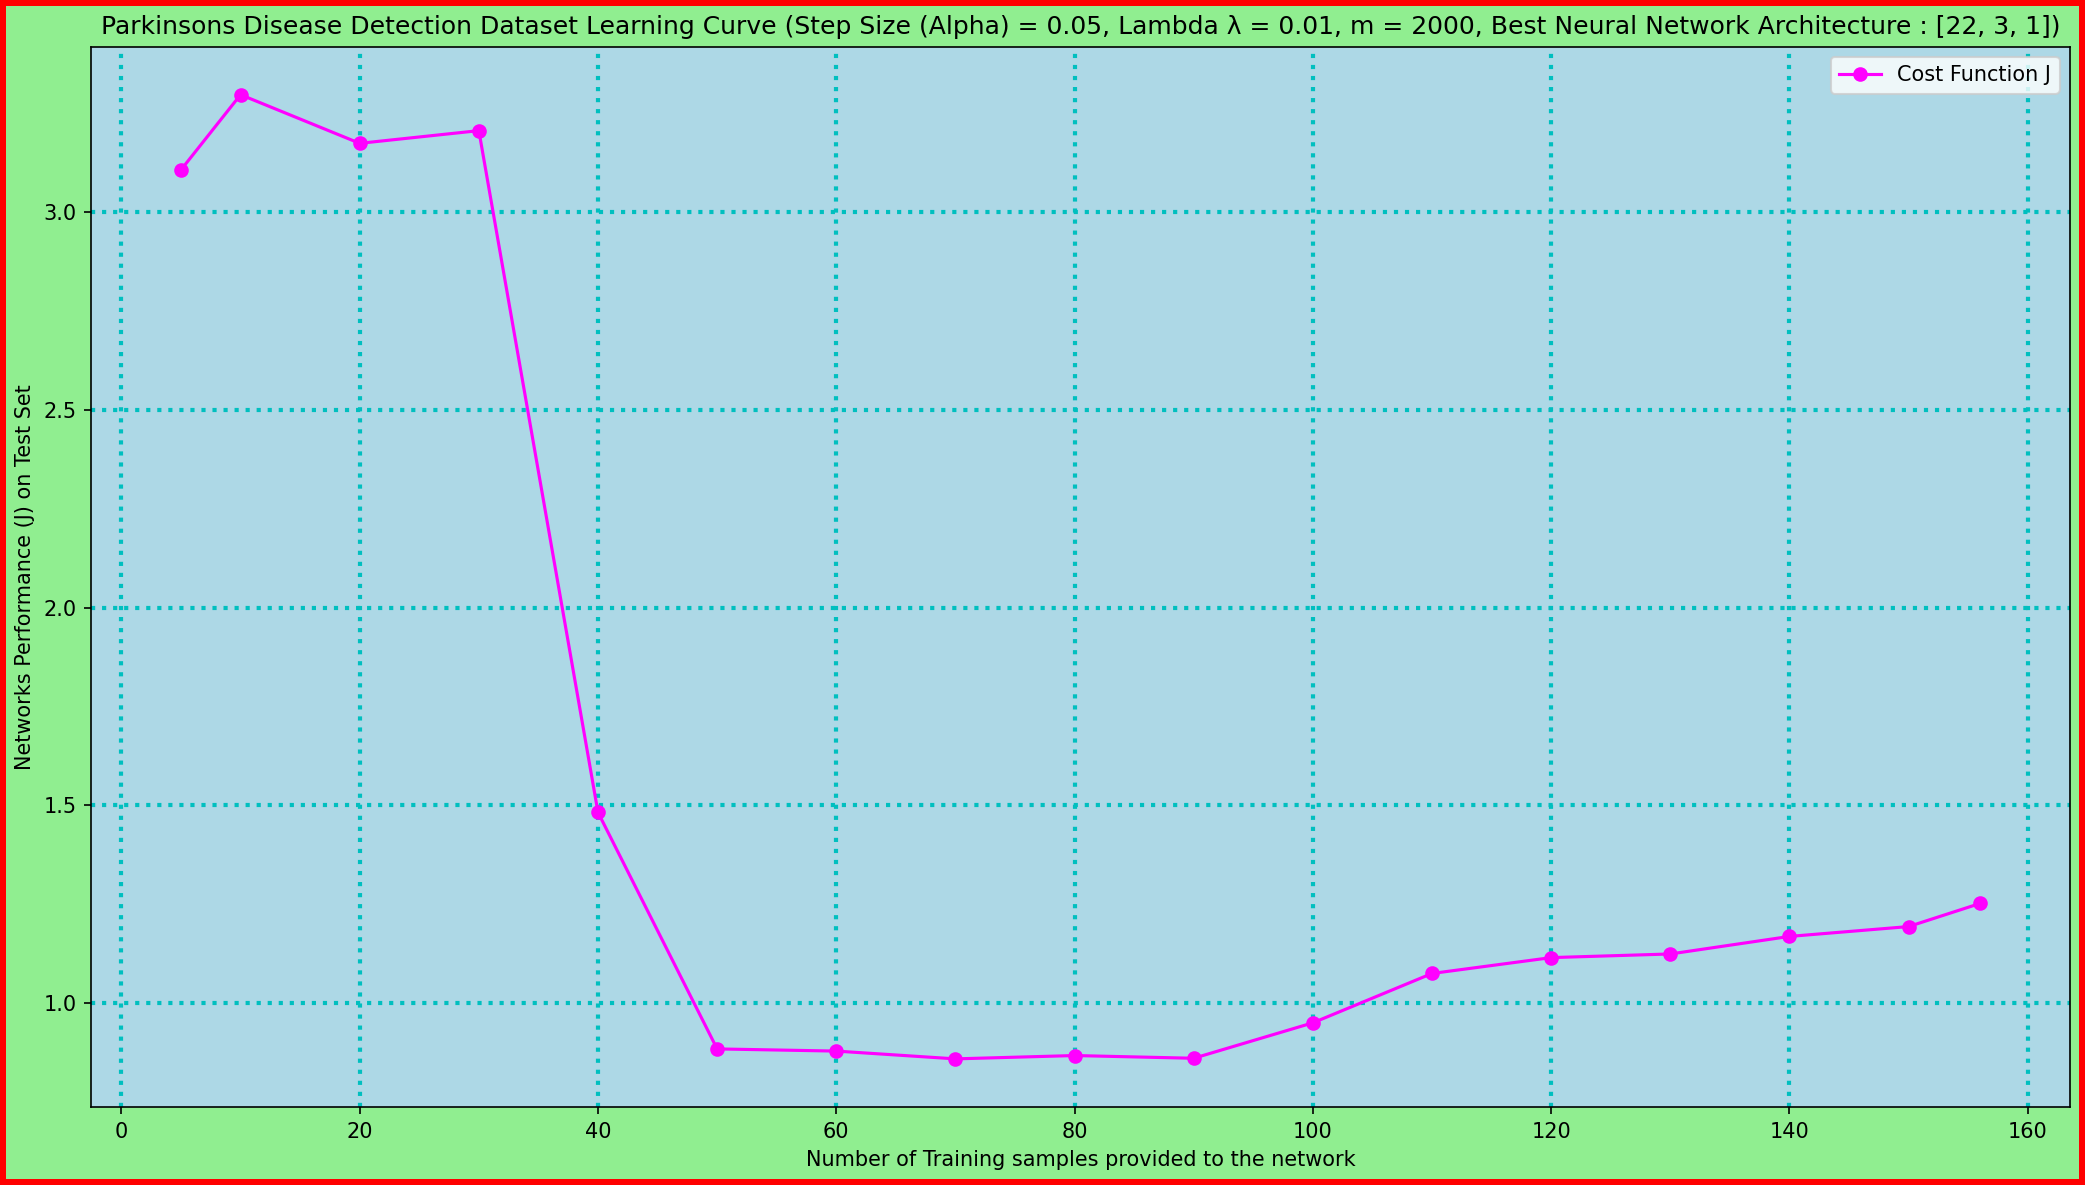

In [59]:
#### Final Project - Mohan Kumar Paramasivan - Dataset 2 ####
#### The Oxford Parkinson’s Disease Detection Dataset ####
#### Algorithm 1 - Neural Networks ####

import matplotlib.pyplot as plt

#### Best architecture for Parkinsons Disease
layer_sizes = [22, 3, 1]
#### Step size value alpha = 0.05
alpha = 0.05
#### Regularization parameter lambda
lambda_ = 0.01

#### Parkinsons Disease Detection dataset has 195 records : 80% records for training instances (156 records) and 20% records for testing instances (39 records)
X_train_full = X_Parkinsons[:156]
#### select first 156 rows for training set from Parkinsons Disease Detection dataset
X_test = X_Parkinsons[156:]
#### selects the remaining rows for test set from Parkinsons Disease Detection dataset
y_train_full = Y_Parkinsons[:156]
#### select first 156 rows for training set from Parkinsons Disease Detection dataset
y_test = Y_Parkinsons[156:]
#### selects the remaining rows for test set from Parkinsons Disease Detection dataset

##### Normalizes the training and testing dataset
X_train_full, X_test = normalize(X_train_full, X_test)

#### Training size - Number of training examples increases progressively
training_sizes = [5, 10, 20, 30, 40, 50, 60, 70, 80, 90, 100, 110, 120, 130, 140, 150, 156]

#### Initialize a cost function list with empty values. J_value is used to store the average of the cost function for each training size
J_values = []

for size in training_sizes:
    #### for each training size iterate the for loop
    #### Picks the subset of training instances based on the training size
    X_subset = X_train_full[:size]
    y_subset = y_train_full[:size]


    #### Initialize random weights for each layer of the neural network
    Thetas = initialize_weights(layer_sizes)
    #### Trains the neural network by repeating the forward and backward propagation m times for the subset of the training instances
    Thetas = train(X_subset, y_subset, Thetas, alpha, lambda_, m = 2000)

    #### Initialize the J_list as a empty list for test set
    J_list = []
    for j, (x, y) in enumerate(zip(X_test, y_test)):
        _, J = forward_propagation(x, np.array([y]), Thetas, j)
        #### obtaining the cost function from the forward propagatgion function for the test set
        J_list.append(J)
        #### repeating the cost function and adding the cost function value result for each test instance to J_list list

    #### Calculate the mean value of cost function for each training size and corresponding test size
    J_values.append(np.mean(J_list))
    print(f'Size: {size}, J: {np.mean(J_list):.5f}')

#### plot
plt.figure(figsize=(14,8), dpi=150.0, facecolor='lightgreen', edgecolor='red', linewidth=5.0, frameon=True, layout='tight')
plt.plot(training_sizes, J_values,  marker='o', color='magenta', label='Cost Function J')
plt.xlabel('Number of Training samples provided to the network')
plt.ylabel('Networks Performance (J) on Test Set')
plt.title('Parkinsons Disease Detection Dataset Learning Curve (Step Size (Alpha) = 0.05, Lambda λ = 0.01, m = 2000, Best Neural Network Architecture : [22, 3, 1])')
plt.grid(True, axis='both', color='c', linestyle=':', linewidth=2.0, alpha=1.0)
plt.legend()
plt.gca().set_facecolor('lightblue')
plt.savefig('Parkinsons_Disease_Detection_Dataset_Learning_curve.pdf')
plt.show()

In [177]:
#### Final Project - Mohan Kumar Paramasivan - Dataset 2 ####
#### The Oxford Parkinson’s Disease Detection Dataset ####
#### Algorithm 2 : K-Nearest Neighbour (K-NN) Algorithm ####


#### KNN calculation function from HW 1 ####

import numpy as np

def knn_calculation(x_train_norm, y_train, X, k):

    distance = np.sqrt(np.sum((x_train_norm - X)**2, axis = 1))
    #### knn algorthim hyperparameter (distance k) is calculated based on Euclidean Distance ####

    #### argsort(distance) = returns the indices sorted in ascending order ####
    #### [:k] = picks only the top k nearest neighbours from the ordered indices ####
    distance_sort = np.argsort(distance)[:k] 

    #### y_train[distance_sort] = Picks the y labels for the indices selected in previous step   ####
    k_labels_indices = y_train[distance_sort]

    #### bincount(k_labels_indices) = counts the occurrences of each integer label ####
    #### argmax() = returns the index with the highest count ####
    prediction = np.bincount(k_labels_indices).argmax()

    return prediction

In [179]:
#### Final Project - Mohan Kumar Paramasivan - Dataset 2 ####
#### The Oxford Parkinson’s Disease Detection Dataset ####
#### Algorithm 2 : K-Nearest Neighbour (K-NN) Algorithm ####


#### cross_validate_knn created based on cross_validate_rf from homework 3 specifically for KNN algorithm ####
#### k is chosen as 10 based on final project requirement (Use stratified cross-validation with k = 10) ####
def cross_validate_knn(X, y, k_neighbors, k=10):
    
    folds = create_stratified_folds(X, y, k)
    #### creates num_folds = 10 stratified folds of the dataset ####
    
    #### initial empty list created for accuracy_scores, f1_scores for both training and testing instances ####
    train_accuracy_scores = []
    test_accuracy_scores = []
    train_f1_scores = []
    test_f1_scores = []

    #### the for loop iterates for each fold ####  
    for i in range(k):
        
        #### the selected fold is choosen as the test indices ####
        #### the values in the folds are converted in to numpy array ####
        test_indices  = np.array(folds[i])

        #### for j in range(k) for j != i : it picks the rest of the folds other than the test fold for training indices ####
        #### the values in the folds are converted in to numpy array ####
        train_indices = np.array([idx for j in range(k) if j != i for idx in folds[j]])
        
        #### divides the training indices into X_train and y_train ####
        X_train, y_train = X[train_indices], y[train_indices]
        #### divides the testing indices into X_test and y_test ####
        X_test,  y_test  = X[test_indices],  y[test_indices]

        ##### Normalizes the training and testing data based on the Normalize function created in HW 4 ####
        X_train, X_test = normalize(X_train, X_test)
        

        #### predictions on training set ####
        y_pred_train = np.array([knn_calculation(X_train, y_train, x, k_neighbors) for x in X_train])
        #### predictions on test set ####
        y_pred_test = np.array([knn_calculation(X_train, y_train, x, k_neighbors) for x in X_test])

        #### Calculates and stores the performance metrics on the k-1 folds (training instances) ####
        train_accuracy_scores.append(accuracy(y_train, y_pred_train))
        train_f1_scores.append(f1_score(y_train, y_pred_train))
        #### Calculates and stores the performance metrics on the kth fold (test instances) ####
        test_accuracy_scores.append(accuracy(y_test, y_pred_test))
        test_f1_scores.append(f1_score(y_test, y_pred_test))

        
    return {
        'Train Accuracy': round(float(np.mean(train_accuracy_scores)), 6),
        'Test Accuracy':  round(float(np.mean(test_accuracy_scores)), 6),
        'Train F1 Score': round(float(np.mean(train_f1_scores)), 6),
        'Test F1 Score':  round(float(np.mean(test_f1_scores)), 6)
    }

In [195]:
#### Final Project - Mohan Kumar Paramasivan - Dataset 2 ####
#### The Oxford Parkinson’s Disease Detection Dataset ####
#### Algorithm 2 : K-Nearest Neighbour (K-NN) Algorithm ####

#### convert Y_Parkinsons from float to int ####
#### np.bincount(k_labels_indices) in knn_calculation function will work only on int and not float ####
Y_Parkinsons_int = Y_Parkinsons.astype(int)

#### K-NN algorithm hyperparameter k is assigned odd value between 1 to 51 incrementing by 2 ####
k_values = range(1, 52, 2)  #class range(start, stop, step) 

#### initializing empty list to store average accuracy of testing and training instances ####
train_means = []
test_means = []
train_stds = []
test_stds = []
#### initializing empty list to store average f1 score of testing and training instances ####
train_f1_means = []
test_f1_means = []
train_f1_stds = []
test_f1_stds = []

#### for loop iterates for each k value ####
for k in k_values:
    print(f'k = {k}')
    #### initializing empty list to store training and testing accuracy for each k value ####
    train_accuracies = []
    test_accuracies = []
    #### initializing empty list to store training and testing f1 score for each k value ####
    train_f1s = []
    test_f1s = []

    #### HW 1 Guidelines : For each value of k, you should run the process described above 20 times ####
    for run in range(20):
        #### np.random.permutation : Generates a random ordering of the indices for all records of Parkinsons dataset ####
        indices = np.random.permutation(len(X_Parkinsons))
        #### Shuffled features of Parkinsons dataset ####
        X_shuffled = X_Parkinsons[indices]
        #### Shuffled labels of Parkinsons dataset ####
        Y_shuffled = Y_Parkinsons_int[indices]
        
        #### Calling the cross_validate_knn function defined in previous step ####
        result = cross_validate_knn(X_shuffled, Y_shuffled, k)        

        #### The Accuracy and F1 Score are added to the list initialized earlier ####
        train_accuracies.append(result['Train Accuracy'])
        test_accuracies.append(result['Test Accuracy'])
        train_f1s.append(result['Train F1 Score'])
        test_f1s.append(result['Test F1 Score'])

    #### The mean and std deviation of Accuracy for all 20 iterations are added to the list initialized earlier ####
    train_means.append(np.mean(train_accuracies))
    test_means.append(np.mean(test_accuracies))
    train_stds.append(np.std(train_accuracies))
    test_stds.append(np.std(test_accuracies))

    #### The mean and std deviation of F1 Score for all 20 iterations are added to the list initialized earlier ####
    train_f1_means.append(np.mean(train_f1s))
    test_f1_means.append(np.mean(test_f1s))
    train_f1_stds.append(np.std(train_f1s))
    test_f1_stds.append(np.std(test_f1s))

    #### [-1] : last value added to the list ####
    #### prints the last value for accuracy and f1 score for current k value ####
    print(f'Train Accuracy: {train_means[-1]:.6f}')
    print(f'Test Accuracy:  {test_means[-1]:.6f}')
    print(f'Train F1 Score: {train_f1_means[-1]:.6f}')
    print(f'Test F1 Score:  {test_f1_means[-1]:.6f}')

k = 1
Train Accuracy: 1.000000
Test Accuracy:  0.958731
Train F1 Score: 1.000000
Test F1 Score:  0.972024
k = 3
Train Accuracy: 0.977407
Test Accuracy:  0.933386
Train F1 Score: 0.984844
Test F1 Score:  0.955362
k = 5
Train Accuracy: 0.959371
Test Accuracy:  0.929589
Train F1 Score: 0.973034
Test F1 Score:  0.953452
k = 7
Train Accuracy: 0.945213
Test Accuracy:  0.917371
Train F1 Score: 0.964176
Test F1 Score:  0.946224
k = 9
Train Accuracy: 0.937616
Test Accuracy:  0.906712
Train F1 Score: 0.959611
Test F1 Score:  0.940283
k = 11
Train Accuracy: 0.923046
Test Accuracy:  0.891402
Train F1 Score: 0.950451
Test F1 Score:  0.930989
k = 13
Train Accuracy: 0.909146
Test Accuracy:  0.871067
Train F1 Score: 0.942186
Test F1 Score:  0.919622
k = 15
Train Accuracy: 0.885838
Test Accuracy:  0.849937
Train F1 Score: 0.928528
Test F1 Score:  0.908039
k = 17
Train Accuracy: 0.861472
Test Accuracy:  0.829114
Train F1 Score: 0.914745
Test F1 Score:  0.896883
k = 19
Train Accuracy: 0.843617
Test Accur

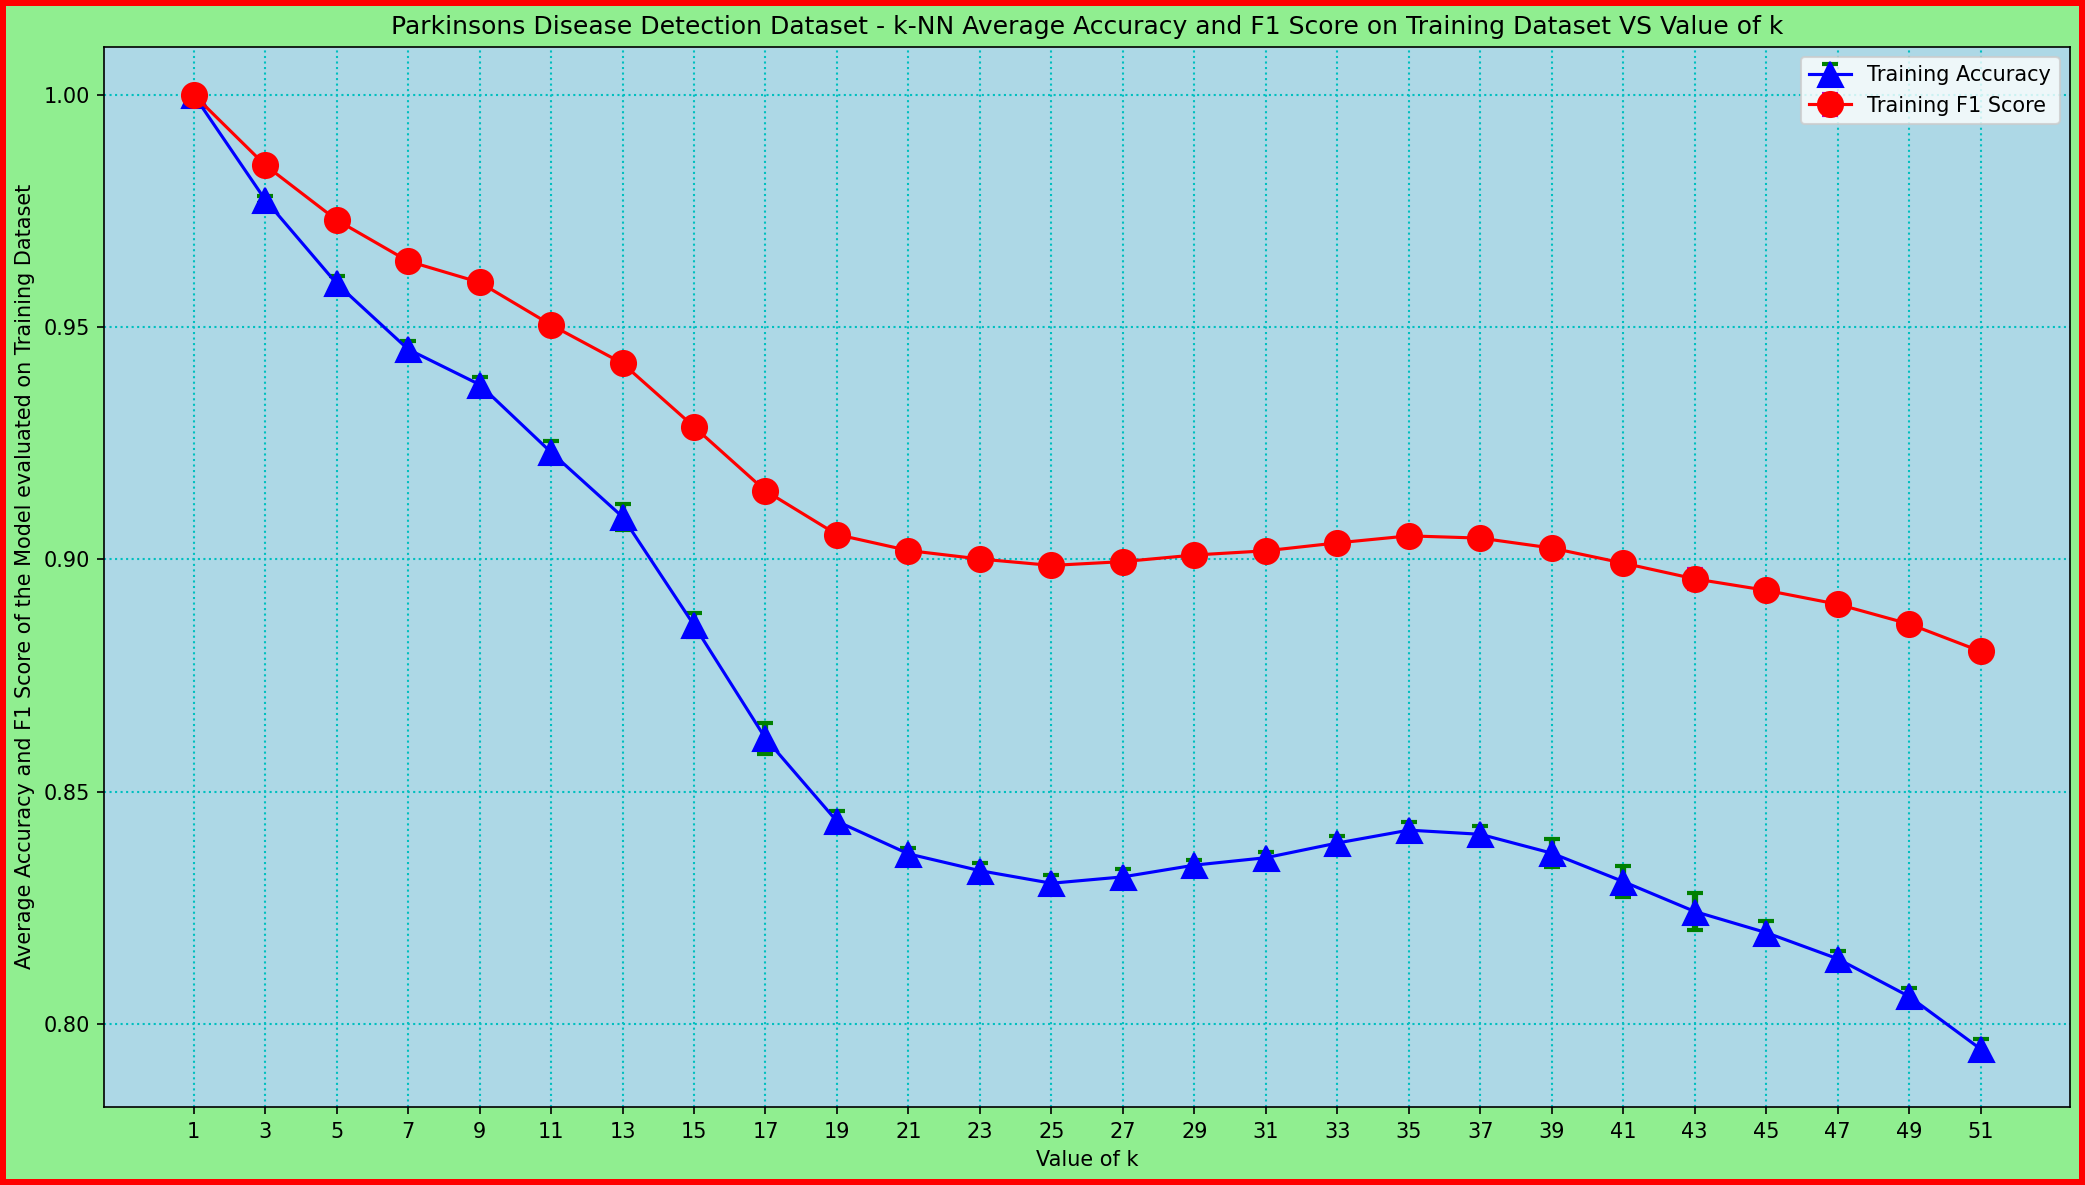

In [197]:
#### Final Project - Mohan Kumar Paramasivan - Dataset 2 ####
#### The Oxford Parkinson’s Disease Detection Dataset ####
#### Algorithm 2 : K-Nearest Neighbour (K-NN) Algorithm ####

#### The average accuracy and F1 score of models evaluated on the training set, given that particular value of k ####
#### Created based on HW 1 Graphs ####

import matplotlib.pyplot as plt

plt.figure(figsize=(14,8), dpi = 150.0, facecolor = 'lightgreen', edgecolor = 'red', linewidth = 5.0, frameon = True, layout = 'tight')

plt.errorbar(
    x = k_values,
    y = train_means,
    xerr = None,
    yerr = train_stds,
    fmt = '^-', 
    label = 'Training Accuracy',
    markersize = 12.0,
    color = 'b',
    capsize = 4,
    capthick = 2,
    ecolor = 'g',
    elinewidth = 3.0,
    barsabove = False,
    errorevery = 1)

plt.errorbar(
    x = k_values,
    y = train_f1_means,
    xerr = None, 
    yerr = train_f1_stds,
    fmt = 'o-', 
    label = 'Training F1 Score', 
    markersize = 12.0, 
    color = 'r',
    capsize = 4, 
    capthick = 2, 
    ecolor = 'm', 
    elinewidth = 3.0, 
    barsabove = False, 
    errorevery = 1)

plt.xticks(k_values)
plt.xlabel("Value of k")
plt.ylabel("Average Accuracy and F1 Score of the Model evaluated on Training Dataset")
plt.title("Parkinsons Disease Detection Dataset - k-NN Average Accuracy and F1 Score on Training Dataset VS Value of k")
plt.grid(True, axis = 'both', color = 'c', linestyle = ':', linewidth = 1.0, alpha = 1.0)
plt.legend()
plt.gca().set_facecolor('lightblue')
plt.savefig('Parkinsons_kNN_Training_Performance_vs_k.pdf')

plt.show()

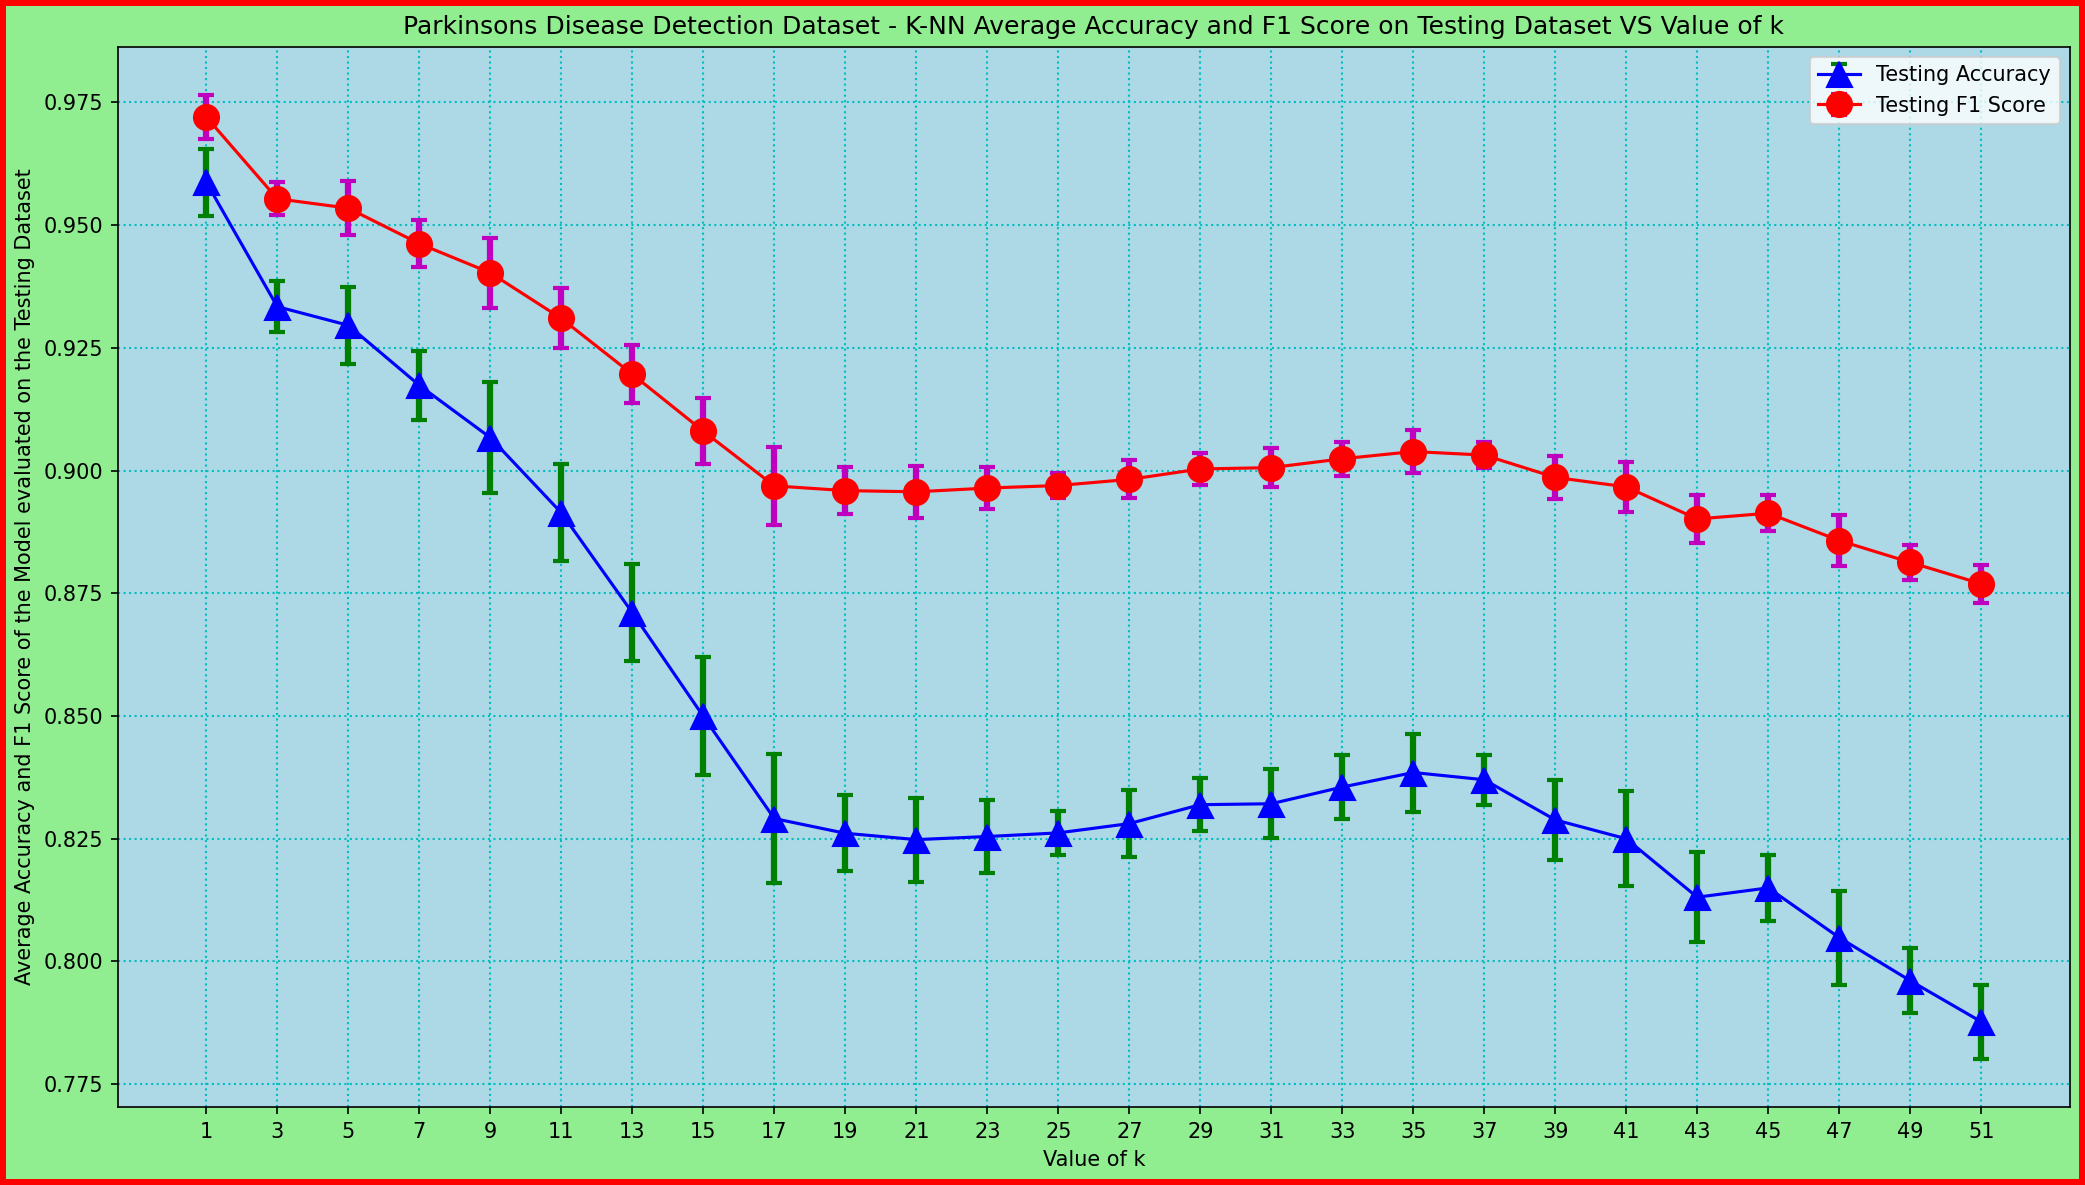

In [199]:
#### Final Project - Mohan Kumar Paramasivan - Dataset 2 ####
#### The Oxford Parkinson’s Disease Detection Dataset ####
#### Algorithm 2 : K-Nearest Neighbour (K-NN) Algorithm ####

#### The average accuracy of models evaluated on the testing set, given that particular value of k. ####
#### Created based on HW 1 Graphs ####

plt.figure(figsize = (14,8), dpi = 150.0, facecolor = 'lightgreen', edgecolor = 'red', linewidth = 5.0, frameon = True, layout = 'tight')

plt.errorbar(
    x = k_values,
    y = test_means,
    xerr = None,
    yerr = test_stds,
    fmt = '^-',
    label = 'Testing Accuracy',
    markersize = 12.0,
    color = 'b',
    capsize = 4,
    capthick = 2, 
    ecolor = 'g',
    elinewidth = 3.0, 
    barsabove = False, 
    errorevery = 1
)

plt.errorbar(
    x = k_values, 
    y = test_f1_means, 
    xerr = None, 
    yerr = test_f1_stds,
    fmt = 'o-', 
    label = 'Testing F1 Score', 
    markersize = 12.0, 
    color = 'r',
    capsize = 4, 
    capthick = 2, 
    ecolor = 'm', 
    elinewidth = 3.0, 
    barsabove = False, 
    errorevery = 1
)

plt.xticks(k_values)
plt.xlabel("Value of k")
plt.ylabel("Average Accuracy and F1 Score of the Model evaluated on the Testing Dataset")
plt.title("Parkinsons Disease Detection Dataset - K-NN Average Accuracy and F1 Score on Testing Dataset VS Value of k")
plt.grid(True, axis = 'both', color = 'c', linestyle = ':', linewidth = 1.0, alpha = 1.0)
plt.legend()
plt.gca().set_facecolor('lightblue')
plt.savefig('Parkinsons_kNN_Testing_Performance_vs_k.pdf')

plt.show()

In [204]:
#### Final Project - Mohan Kumar Paramasivan - Dataset 2 ####
#### The Oxford Parkinson’s Disease Detection Dataset ####
#### Algorithm 3 - Random Forest ####

#### Added in HW 3 ####
#### A procedure to create bootstrap datasets by sampling (with replacement) from the current training set ####

import numpy as np

def bootstrap_dataset(X, y):

    number_of_records = X.shape[0] #### Gets the total number of instances in dataset ####
    #### X.shape returns a tuple (instances, attributes) of a dataset e.g (569, 30) for WDBC ####
    #### shape[0] is number of instances ####
    #### shape[1] is number of features/attributes ####

    records = np.random.choice(number_of_records, size = number_of_records, replace = True, p = None)
    #### random.choice(a, size=None, replace=True, p=None)
    #### Parameters : a : 1-D array-like or int, - If an ndarray, a random sample is generated from its elements
    #### size = int or tuple of ints, optional, - Output shape. eg if value is 5, then 5 samples are drawn
    #### replace : boolean, optional, - Whether the sample is with or without replacement. Default is True, meaning that a value of a can be selected multiple times
    #### p : 1-D array-like, optional, - The probabilities associated with each entry in a


    #### X[records] uses the sampled indices to select features or instances from X ####
    #### y[records] uses the sampled indices to select labels from y ####
    #### Both are returned together to keep features and labels in sync
    return X[records], y[records]

In [206]:
#### Final Project - Mohan Kumar Paramasivan - Dataset 2 ####
#### The Oxford Parkinson’s Disease Detection Dataset ####
#### Algorithm 3 - Random Forest ####

#### Added in HW 3 ####
#### a majority voting mechanism that takes into account the predictions made by each tree
#### in the ensemble to classify new instances

from collections import Counter

def majority_vote(predictions):    
    vote_counts = Counter(predictions)  
    #### predictions is a list of predictions from all trees ####
    #### A Counter is a dict subclass for counting hashable objects. 
    #### It is a collection where elements are stored as dictionary keys and their counts are stored as dictionary values. 
    
    #### most_common(n) - Return a list of the n most common elements and their counts from the most common to the least e.g. [('malignant', 3), ('benign', 2)]
    #### [0] picks the first tuple in the list e.g. (malignant, 3)
    #### [0][0] picks the first element from the tuple e.g. 'malignant'
    return vote_counts.most_common(1)[0][0]

In [208]:
#### Final Project - Mohan Kumar Paramasivan - Dataset 2 ####
#### The Oxford Parkinson’s Disease Detection Dataset ####
#### Algorithm 3 - Random Forest ####

#### From HomeWork 1 ####

import numpy as np

def entropy(column_name):
# definition for entropy calculation, the parameter used is the column name
    
    counts = column_name.value_counts(normalize = True) 
    # value_counts = returns the count of each of the unique values in the series
    # normalize = If True, returns the counts as a percentage of the total rather than the actual counts

    entropy = 0

    for count in counts:
        entropy -= (count * np.log2(count))

    return entropy

In [210]:
#### Final Project - Mohan Kumar Paramasivan - Dataset 2 ####
#### The Oxford Parkinson’s Disease Detection Dataset ####
#### Algorithm 3 - Random Forest ####

#### From HomeWork 1 ####
#### UPDATED IN HW 3 ####

def average_entropy(dataframe, feature, column_name = "class"):

    TOTAL = len(dataframe)  # len() = Return the length (the number of items) of an object.
    AVG_entropy = 0

    #### UPDATED IN HW 3 - Included average entropy calculation logic for numerical attributes ####
    if '_num' in feature:
        #### check if the feature is a numerical attributes ####
        threshold = dataframe[feature].mean()
        
        #### calculate the mean of the numerical feature values in the dataframe
        
        left  = dataframe[dataframe[feature] <= threshold]
        #### left subset : instances where feature values <= threshold
        right = dataframe[dataframe[feature] >  threshold]
        #### right subset : instances where feature values > threshold

        for subset in [left, right]:
            #### loops through both left and right subsets ####
            if len(subset) == 0:
                #### if subset is empty skip it ####
                continue
            weight = len(subset) / TOTAL  # Computes |D_j| / |D| = proportion of instances in partition D_j after splitting on threshold mean value

            subset_entropy = entropy(subset[column_name]) # Computes the entropy of the subset corresponding to a specific value of the selected attribute
            
            AVG_entropy += weight * subset_entropy # Accumulates |D_j| / |D| * I(D_j) to compute Info_A(D), the average entropy after splitting on attribute A

    else:
        
        for value in dataframe[feature].unique():
        # unique() = Returns the unique value in selected column

            subset = dataframe[dataframe[feature] == value]

            weight = len(subset) / TOTAL  # Computes |D_j| / |D| = proportion of instances in partition D_j after splitting on attribute A
        
            subset_entropy = entropy(subset[column_name]) # Computes the entropy of the subset corresponding to a specific value of the selected attribute

        #print(value, weight, subset_entropy)

            AVG_entropy += weight * subset_entropy
        # Accumulates |D_j| / |D| * I(D_j) to compute Info_A(D), the average entropy after splitting on attribute A

    return AVG_entropy

In [212]:
#### Final Project - Mohan Kumar Paramasivan - Dataset 2 ####
#### The Oxford Parkinson’s Disease Detection Dataset ####
#### Algorithm 3 - Random Forest ####

#### From HomeWork 1 ####

def information_gain(dataframe,column_name,feature):

    Entropy_of_Dataset = entropy(dataframe[column_name])
    Average_Entropy_of_Partition = average_entropy(dataframe, feature)

    Information_Gain = (Entropy_of_Dataset - Average_Entropy_of_Partition)

    return Information_Gain

In [214]:
#### Final Project - Mohan Kumar Paramasivan - Dataset 2 ####
#### The Oxford Parkinson’s Disease Detection Dataset ####
#### Algorithm 3 - Random Forest ####

#### From HomeWork 1 ####

def best_feature(dataframe, column_name, features):
    if not features:
        return None
        
    Info_Gain = {}  # Initialize an empty dictionary to store Information Gain values
   
    for attribute in features:
        Info_Gain[attribute] = information_gain(dataframe, column_name, attribute) 
        # Compute Information Gain for the current attribute and store it in the dictionary using the attribute name as the key
        
        # print("Information Gain for", attribute, "is", Info_Gain[attribute])

    if not Info_Gain:
        return None
        
    Best_Feature = pd.Series(Info_Gain).sort_values(ascending=False).index[0]
    # pd.Series = Convert dictionary to pandas Series, sort features by Information Gain in descending order,
    # and select the feature with the highest Information Gain
    # print(Best_Feature)
    return Best_Feature

In [216]:
#### Final Project - Mohan Kumar Paramasivan - Dataset 2 ####
#### The Oxford Parkinson’s Disease Detection Dataset ####
#### Algorithm 3 - Random Forest ####

#### From HomeWork 1 ####

# Function used to return the majority class label in the dataframe target column
def majority_class(dataframe, column_name):
    counts = dataframe[column_name].value_counts()
    majority = counts.sort_values(ascending=False).index[0]
    
    return majority

In [218]:
#### Final Project - Mohan Kumar Paramasivan - Dataset 2 ####
#### The Oxford Parkinson’s Disease Detection Dataset ####
#### Algorithm 3 - Random Forest ####

#### From HomeWork 1 ####
#### UPDATED IN HW 3 ####

import random
import math

#### UPDATED IN HW 3 - Added new parameters - maximum_depth, minimum_size_for_split, depth
def build_tree(dataframe, column_name, features, maximum_depth = 10, minimum_size_for_split = 5, depth = 0):
    #### maximum_depth : stop splitting whenever the current branch of the tree becomes too deep, 
    #### that is, when its depth exceeds some pre-defined value that you select empirically
    
    #### minimum_size_for_split : stop splitting nodes whenever the data partition associated with the current node contains fewer than n instances, 
    #### for some value of n that you choose empirically

    #### depth : tracks the current depth of the tree 
    #### initial value is set to 0 and increases by 1 for each split

    # If all instances in belong to the same class, Define node as a leaf node labeled with y and return it
    if dataframe[column_name].nunique() == 1:  # nunique() - returns the number of unique values in a column
        return {"is_leaf": True, "label": dataframe[column_name].iloc[0]}

    #### UPDATED in HW 3 - Not needed for random forest ####
    #  If there are no more attributes that can be tested, Define node as a leaf node labeled with the majority class in , and return it
    #### if len(features) == 0:
        #### return {"is_leaf": True, "label": majority_class(dataframe, column_name)}

    #### UPDATED IN HW 3 ####
    if depth >= maximum_depth:
        #### depth starts from 0 and increases by 1 after each split
        #### maximum_depth : stop splitting whenever the current branch of the tree becomes too deep, 
        #### that is, when its depth exceeds some pre-defined value

        #### makes the current node a leaf node
        #### majority_class picks the most common label from the current node dataframe
        return {"is_leaf": True, "label": majority_class(dataframe, column_name)}


    #### UPDATED IN HW 3 ####
    if len(dataframe) < minimum_size_for_split:
        #### minimum_size_for_split : stop splitting nodes whenever the data partition associated with the current node contains fewer than n instances, 
        #### for some value of n that you choose empirically

        #### makes the current node a leaf node
        #### majority_class picks the most common label from the current node dataframe        
        return {"is_leaf": True, "label": majority_class(dataframe, column_name)}
    
    node_majority = majority_class(dataframe, column_name)
    
    #### UPDATED IN HW 3 ####
    m_attributes = round(math.sqrt(len(features))) 
    selected_features = random.sample(features, m_attributes)

    best = best_feature(dataframe, column_name, selected_features)

    #### UPDATED IN HW 3 ####
    if best is None or information_gain(dataframe, column_name, best) <= 0.01:
        #### stopping criteria ####
        #### when the best feature is none - no feature found ####
        #### when the information_gain <= 0.01 - split not useful ####
        
        #### makes the current node a leaf node ####
        #### majority_class picks the most common label from the current node dataframe  ####
        return {"is_leaf": True, "label": majority_class(dataframe, column_name)}
    
    #### UPDATED IN HW3 - calculate threshold for numerical features ####
    if '_num' in best:
        threshold = dataframe[best].mean()
        #### if feature is numerical calculate mean as threshold ####
    else:
        threshold = None
        #### if feature is categorical set threshold to None ####
    
    node = {
        "is_leaf": False,
        "feature": best,
        "children": {},
        "majority": node_majority,
        "threshold" : threshold
        #### store threshold in node for use in predict_one() ####
    }
    # Outer dictionary creates the decision node using the best feature,
    # inner empty dictionary will store the branches (subtrees) for each feature value

    
    #### UPDATED in HW 3 - Not needed for random forest ####
    #### remaining_features = features.copy()  #  copy() - returns a shallow copy of the object
    #### remaining_features.remove(best)

    #### UPDATED in HW 3 : Logic for Numerical features ####
    if '_num' in best:
        #### if numerical feature is chosen as the best feature - feature with highest information gain ####
        left  = dataframe[dataframe[best] <= threshold]
        #### left subset: instances where feature value <= threshold ####
        right = dataframe[dataframe[best] >  threshold]
        #### right subset : instances where feature value > threshold ####


        if len(left) == 0 or len(right) == 0:
            #### if split creates empty subset — no useful split ####
            #### make current node a leaf node ####
            return {"is_leaf": True, "label": majority_class(dataframe, column_name)}
               

        for split_name, subset in [('left', left), ('right', right)]:
            #### loops through 2 tuples ('left', left), ('right', right) ####
            #### split name is the name of the branch - 'left' and 'right' ####
            if len(subset) == 0:
                node["children"][split_name] = {"is_leaf": True, "label": node_majority}
                #### if the subset has no instances, then its assigned as leaf node and assigned the majority class as label
            else:
                node["children"][split_name] = build_tree(subset, column_name, features, maximum_depth = maximum_depth,
                                                          minimum_size_for_split = minimum_size_for_split, depth=depth+1)
                #### continue building subtree for this branch ####
    
    else:
        for value in dataframe[best].unique():
            subset = dataframe[dataframe[best] == value]

            #### UPDATED IN HW 3 ####
            if len(subset) == 0:
                node["children"][value] = {"is_leaf": True, "label": node_majority}
            else:
                node["children"][value] = build_tree(subset, column_name, features, maximum_depth = maximum_depth, 
                                                 minimum_size_for_split = minimum_size_for_split, depth = depth+1)
                #### maximum_depth = chosen value passed for next node split
                #### minimum_size_for_split = chosen value passed for next node split
                #### depth + 1 = depth increased by 1 for next node
    
    return node

In [220]:
#### Final Project - Mohan Kumar Paramasivan - Dataset 2 ####
#### The Oxford Parkinson’s Disease Detection Dataset ####
#### Algorithm 3 - Random Forest ####


#### From HomeWork 1 ####
#### UPDATED IN HW 3 : Added the logic for Numerical features ####

def predict_one(tree, row):
    if tree["is_leaf"]: 
        return tree["label"]

    feature = tree["feature"]
    value = row[feature]

    #### UPDATED IN HW 3 : Logic for Numerical features ####
    if '_num' in feature:
        #### checks if the selected feature is a numerical feature ####
        
        threshold = tree["threshold"]
        #### Assigns the threshold value stored in the node from the build_tree() ####

        if value <= threshold:
            #### if the value of the instance of the selected feature is <= threshold, assign to left branch ####
            branch = 'left'
        else:
            #### if the value of the instance of the selected feature is > threshold, assign to right branch ####
            branch = 'right'

        if branch not in tree["children"]:
            #### if the branch is missing from the tree children ####
            return tree.get("majority", None)
            #### returns the majority class of the current node ####

        #### Calls the predict_one function recursively with the child branch as the new node and its value ####
        return predict_one(tree["children"][branch], row)

    else:
        # unknown value
        if value not in tree["children"]:
            return tree.get("majority", None)

        return predict_one(tree["children"][value], row)

def predict_df(tree, dataframe):
    return dataframe.apply(lambda r: predict_one(tree, r), axis=1)

In [222]:
#### Final Project - Mohan Kumar Paramasivan - Dataset 2 ####
#### The Oxford Parkinson’s Disease Detection Dataset ####
#### Algorithm 3 - Random Forest ####


#### Added in HW 3 ####

import pandas as pd
import numpy as np
import math

def train_random_forest(X, y, feature_names, ntree=10, maximum_depth=10, minimum_size_for_split=5):

    forest = []
    #### initializes a list to store trees ####

    for i in range(ntree):
        #### for loop iterates for the value of ntree ####
        #### e.g if ntree = 10, for loop iterates = 0, 1, 2...9 ####

        X_boot, y_boot = bootstrap_dataset(X, y)
        #### bootstrap original dataset for each for loop and assigns to instances and labels ####

        df_boot = pd.DataFrame(X_boot, columns=feature_names)
        #### Converts the Numpy array to pandas DataFrame ####
        #### pd.DataFrame(data, columns = None, index = None) ####
        #### data = the Numpy array to be converted to pandas DataFrame ####
        #### columns assign feature names as column header in the dataframe. Pandas has column names ####
        df_boot['class'] = y_boot
        #### Adds label column name 'class' to the last column of pandas Dataframe ####
        #### assigns the bootstrapped y value from y_boot to the 'class' column ####
        
        tree = build_tree(df_boot, 'class', feature_names,
                         maximum_depth=maximum_depth,
                         minimum_size_for_split=minimum_size_for_split)
        #### builds one decision tree using bootstrap sample ####

        forest.append(tree)
        #### Adds the tree to the forest list at the end of the for loop  ####

    #### returns the forest which has all the trees based on the ntree value ####
    return forest  

In [224]:
#### Final Project - Mohan Kumar Paramasivan - Dataset 2 ####
#### The Oxford Parkinson’s Disease Detection Dataset ####
#### Algorithm 3 - Random Forest ####

#### Added in HW 3 ####

def predict_random_forest(forest, X, feature_names):

    df_test = pd.DataFrame(X, columns=feature_names)
    #### Converts the Numpy array to pandas DataFrame ####
    #### pd.DataFrame(data, columns = None, index = None) ####

    all_predictions = []
    #### initializes a list to store all predictions ####

    for tree in forest:
        #### loops through each tree in the forest ####
        tree_preds = list(predict_df(tree, df_test))
        #### gets predictions from current tree for all instances ####
        #### list() converts Pandas Series to list ####
        all_predictions.append(tree_preds)
        #### Add the list from tree_preds for each tree in the forest ####
        #### all_predictions has multiple list under its list ####

    final_predictions = []
    #### initializes a list to store final predictions ####

    for i in range(len(X)):
        #### len(X) is the length of the instances in the testing dataset ####
        #### for loops iterates for each instances of testing dataset ####
        votes = [all_predictions[t][i] for t in range(len(forest))]
        #### votes has the list of all labels for each instances from each tree in the forest ####
        #### e.g. for instance [0] of the testing dataset ####
        #### all_predictions[0][0], all_predictions[1][0], all_predictions[2][0]... until the length of the forest #### 
        final_predictions.append(majority_vote(votes))
        #### final_predictions stores the majority label for each instances ####

    #### returns final predictions for all instances ####
    return final_predictions

In [226]:
#### Final Project - Mohan Kumar Paramasivan - Dataset 2 ####
#### The Oxford Parkinson’s Disease Detection Dataset ####
#### Algorithm 3 - Random Forest ####

#### Added in HW 3 ####

def cross_validate_rf(X, y, feature_names, ntree=10, k=10, maximum_depth=10, minimum_size_for_split=5):

    folds = create_stratified_folds(X, y, k)
    #### creates k = 10 stratified folds of the dataset ####

    accuracy_scores  = []
    precision_scores = []
    recall_scores    = []
    f1_scores        = []
    #### initial empty list created for accuracy_scores, precision_scores, recall_scores, f1_scores ####

    for i in range(k):
        #### the for loop iterates for each fold ####

        test_indices  = np.array(folds[i])
        #### the selected fold is choosen as the test indices ####
        #### the values in the folds are converted in to numpy array ####
        train_indices = np.array([idx for j in range(k) if j != i for idx in folds[j]])
        #### for j in range(k) for j != i : it picks the rest of the folds other than the test fold for training indices ####
        #### the values in the folds are converted in to numpy array ####

        X_train, y_train = X[train_indices], y[train_indices]
        #### divides the training indices into X_train and y_train ####
        X_test,  y_test  = X[test_indices],  y[test_indices]
        #### divides the testing indices into X_test and y_test ####

        forest = train_random_forest(X_train, y_train, feature_names, ntree=ntree,
                                     maximum_depth=maximum_depth,
                                     minimum_size_for_split=minimum_size_for_split)
        #### trains random forest on k-1 folds ####

        y_pred = predict_random_forest(forest, X_test, feature_names)
        #### performs prediction on the kth fold ####

        accuracy_scores.append(accuracy(y_test,   y_pred))
        precision_scores.append(precision(y_test, y_pred))
        recall_scores.append(recall(y_test,       y_pred))
        f1_scores.append(f1_score(y_test,         y_pred))
        #### calculates and stores metrics for kth fold ####

    return {
        'Accuracy': round(float(np.mean(accuracy_scores)), 6),
        'Precision': round(float(np.mean(precision_scores)), 6),
        'Recall': round(float(np.mean(recall_scores)), 6),
        'F1 Score': round(float(np.mean(f1_scores)), 6)
    }

In [228]:
#### Final Project - Mohan Kumar Paramasivan - Dataset 2 ####
#### The Oxford Parkinson’s Disease Detection Dataset ####
#### Algorithm 3 - Random Forest ####

feature_names_parkinsons = [col + '_num' for col in Parkinsons_disease_dataset.drop(columns=['Diagnosis']).columns]
y_Parkinsons_RF = np.array(Parkinsons_disease_dataset['Diagnosis'].values)
print("The Parkinsons Disease Detection Dataset:")
print("X shape:", X_Parkinsons.shape)
print("y shape:", y_Parkinsons_RF.shape)
print("Features:", feature_names_parkinsons)

The Parkinsons Disease Detection Dataset:
X shape: (195, 22)
y shape: (195,)
Features: ['MDVP:Fo(Hz)_num', 'MDVP:Fhi(Hz)_num', 'MDVP:Flo(Hz)_num', 'MDVP:Jitter(%)_num', 'MDVP:Jitter(Abs)_num', 'MDVP:RAP_num', 'MDVP:PPQ_num', 'Jitter:DDP_num', 'MDVP:Shimmer_num', 'MDVP:Shimmer(dB)_num', 'Shimmer:APQ3_num', 'Shimmer:APQ5_num', 'MDVP:APQ_num', 'Shimmer:DDA_num', 'NHR_num', 'HNR_num', 'RPDE_num', 'DFA_num', 'spread1_num', 'spread2_num', 'D2_num', 'PPE_num']


In [259]:
#### Final Project - Mohan Kumar Paramasivan - Dataset 2 ####
#### The Oxford Parkinson’s Disease Detection Dataset ####
#### Algorithm 3 - Random Forest ####

#### Different values of ntree parameter ####
ntree_values = [1, 5, 10, 20, 30, 40, 50]

#### Create a empty dictionary for parkinsons_rf_results ####
parkinsons_rf_results = {}
for ntree in ntree_values:
    print(f"The Oxford Parkinson’s Disease Detection Dataset - ntree parameter = {ntree}")
    #### Prints the header for each ntree value ####
    parkinsons_rf_results[ntree] = cross_validate_rf(X_Parkinsons, y_Parkinsons_RF, feature_names_parkinsons, ntree=ntree, k=10)
    print(parkinsons_rf_results[ntree])

The Oxford Parkinson’s Disease Detection Dataset - ntree parameter = 1
{'Accuracy': 0.841433, 'Precision': 0.884409, 'Recall': 0.912381, 'F1 Score': 0.896086}
The Oxford Parkinson’s Disease Detection Dataset - ntree parameter = 5
{'Accuracy': 0.908099, 'Precision': 0.929902, 'Recall': 0.951905, 'F1 Score': 0.939584}
The Oxford Parkinson’s Disease Detection Dataset - ntree parameter = 10
{'Accuracy': 0.928626, 'Precision': 0.932157, 'Recall': 0.98, 'F1 Score': 0.95454}
The Oxford Parkinson’s Disease Detection Dataset - ntree parameter = 20
{'Accuracy': 0.90307, 'Precision': 0.92549, 'Recall': 0.952857, 'F1 Score': 0.937282}
The Oxford Parkinson’s Disease Detection Dataset - ntree parameter = 30
{'Accuracy': 0.907251, 'Precision': 0.918435, 'Recall': 0.965714, 'F1 Score': 0.940519}
The Oxford Parkinson’s Disease Detection Dataset - ntree parameter = 40
{'Accuracy': 0.908626, 'Precision': 0.925588, 'Recall': 0.959524, 'F1 Score': 0.940711}
The Oxford Parkinson’s Disease Detection Dataset 

In [261]:
#### Final Project - Mohan Kumar Paramasivan - Dataset 2 ####
#### The Oxford Parkinson’s Disease Detection Dataset ####
#### Algorithm 3 - Random Forest ####

import matplotlib.pyplot as plt

ntree_values = [1, 5, 10, 20, 30, 40, 50]

#### extract metrics for WDBC dataset ####
#### Creates a list and stores the metrics value for each ntree parameter ####
Parkinsons_accuracy  = [parkinsons_rf_results[n]['Accuracy']  for n in ntree_values]
Parkinsons_precision = [parkinsons_rf_results[n]['Precision'] for n in ntree_values]
Parkinsons_recall    = [parkinsons_rf_results[n]['Recall']    for n in ntree_values]
Parkinsons_f1        = [parkinsons_rf_results[n]['F1 Score']  for n in ntree_values]

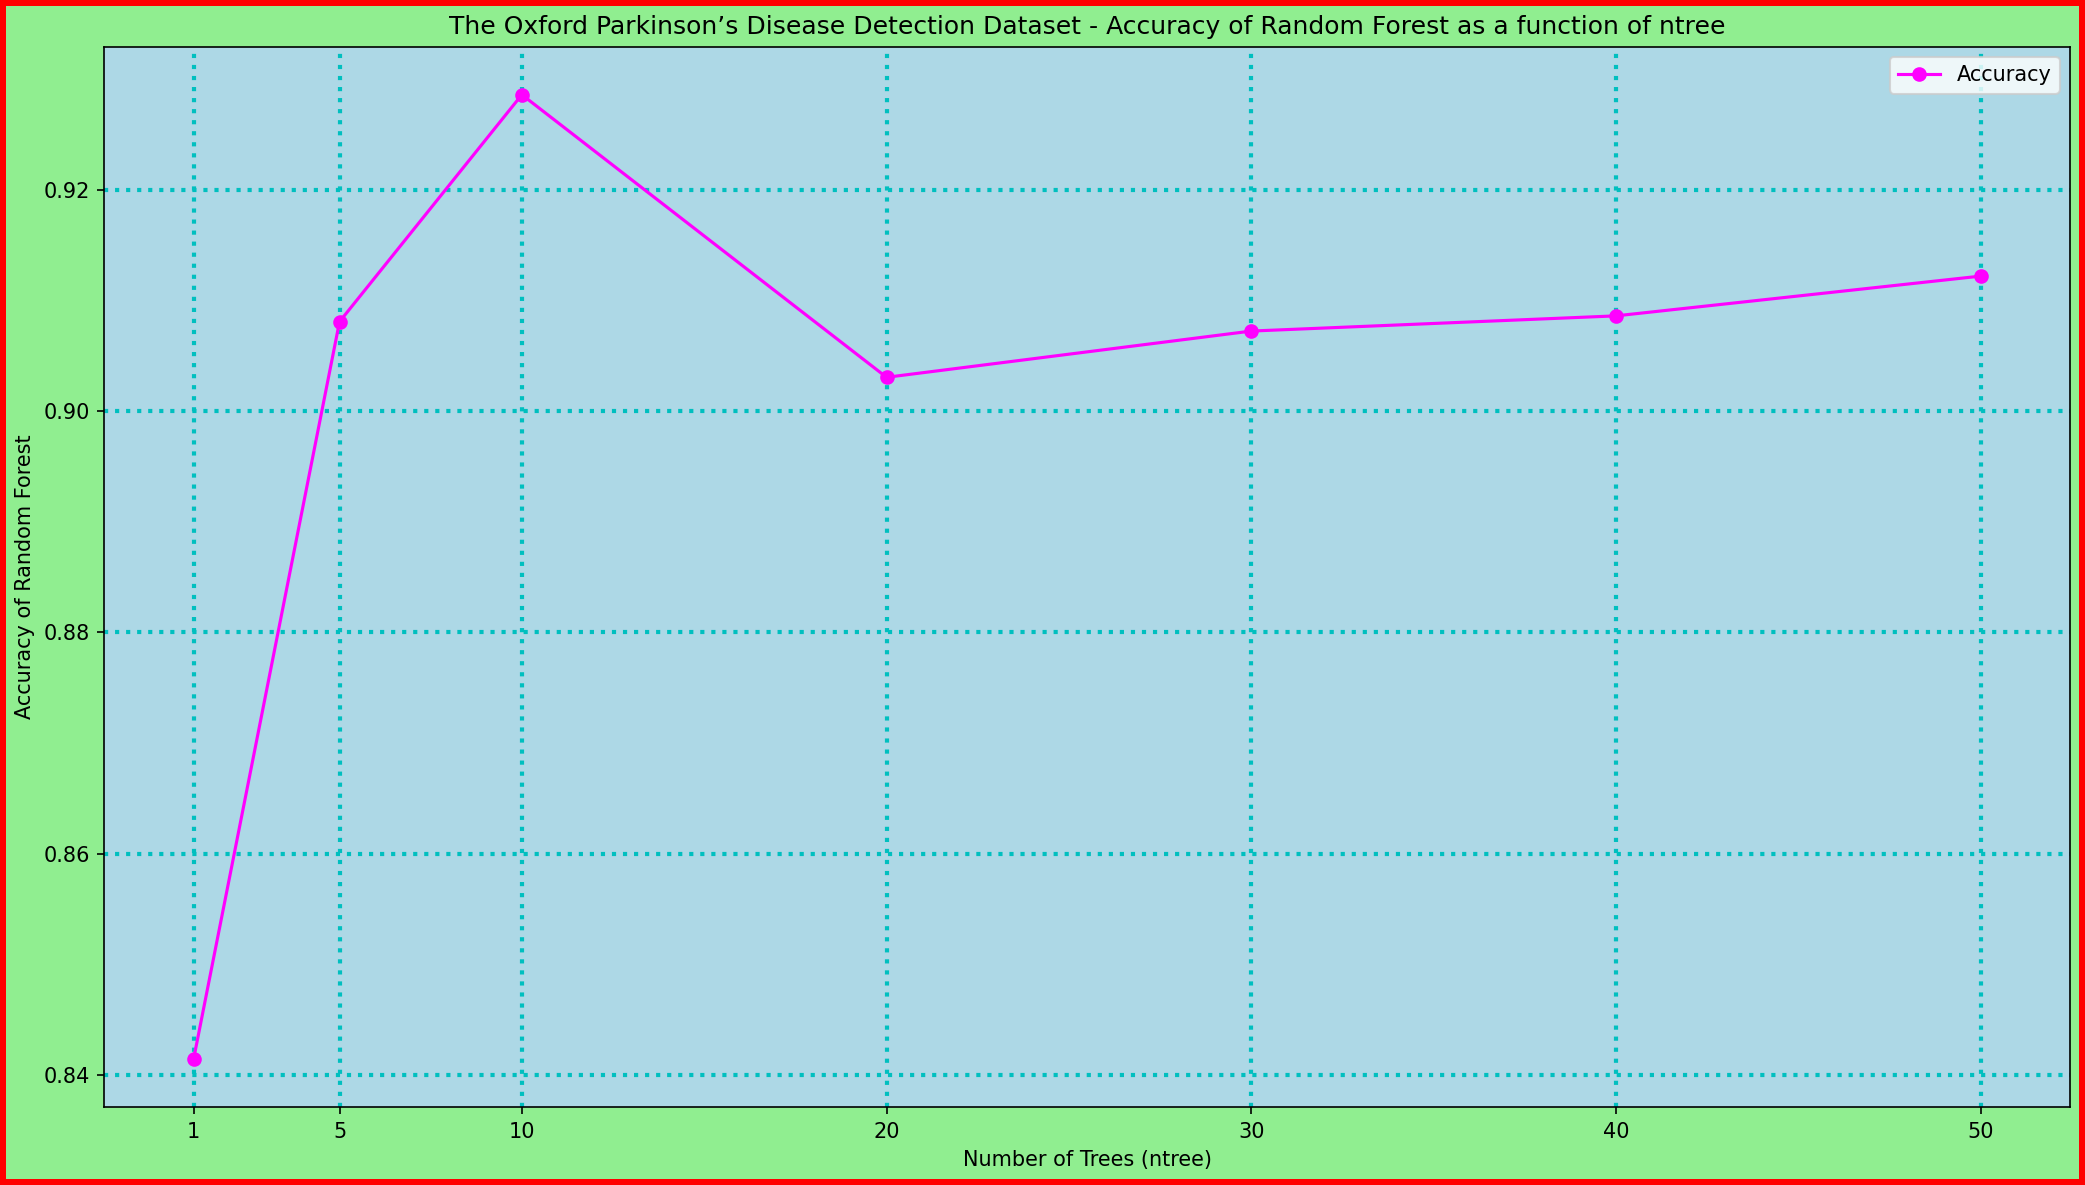

In [263]:
#### Final Project - Mohan Kumar Paramasivan - Dataset 2 ####
#### The Oxford Parkinson’s Disease Detection Dataset ####
#### Algorithm 3 - Random Forest ####

#### Plot 1 - Parkinsons Accuracy ####
plt.figure(figsize=(14,8), dpi=150.0, facecolor='lightgreen', edgecolor='red', linewidth=5.0, frameon=True, layout='tight')
plt.plot(ntree_values, Parkinsons_accuracy, marker='o', color='magenta', label='Accuracy')
plt.xticks(ntree_values)
plt.xlabel('Number of Trees (ntree)')
plt.ylabel('Accuracy of Random Forest')
plt.title('The Oxford Parkinson’s Disease Detection Dataset - Accuracy of Random Forest as a function of ntree')
plt.grid(True, axis='both', color='c', linestyle=':', linewidth=2.0, alpha=1.0)
plt.legend()
plt.gca().set_facecolor('lightblue')
plt.savefig('Parkinsons_Accuracy.pdf')
plt.show()

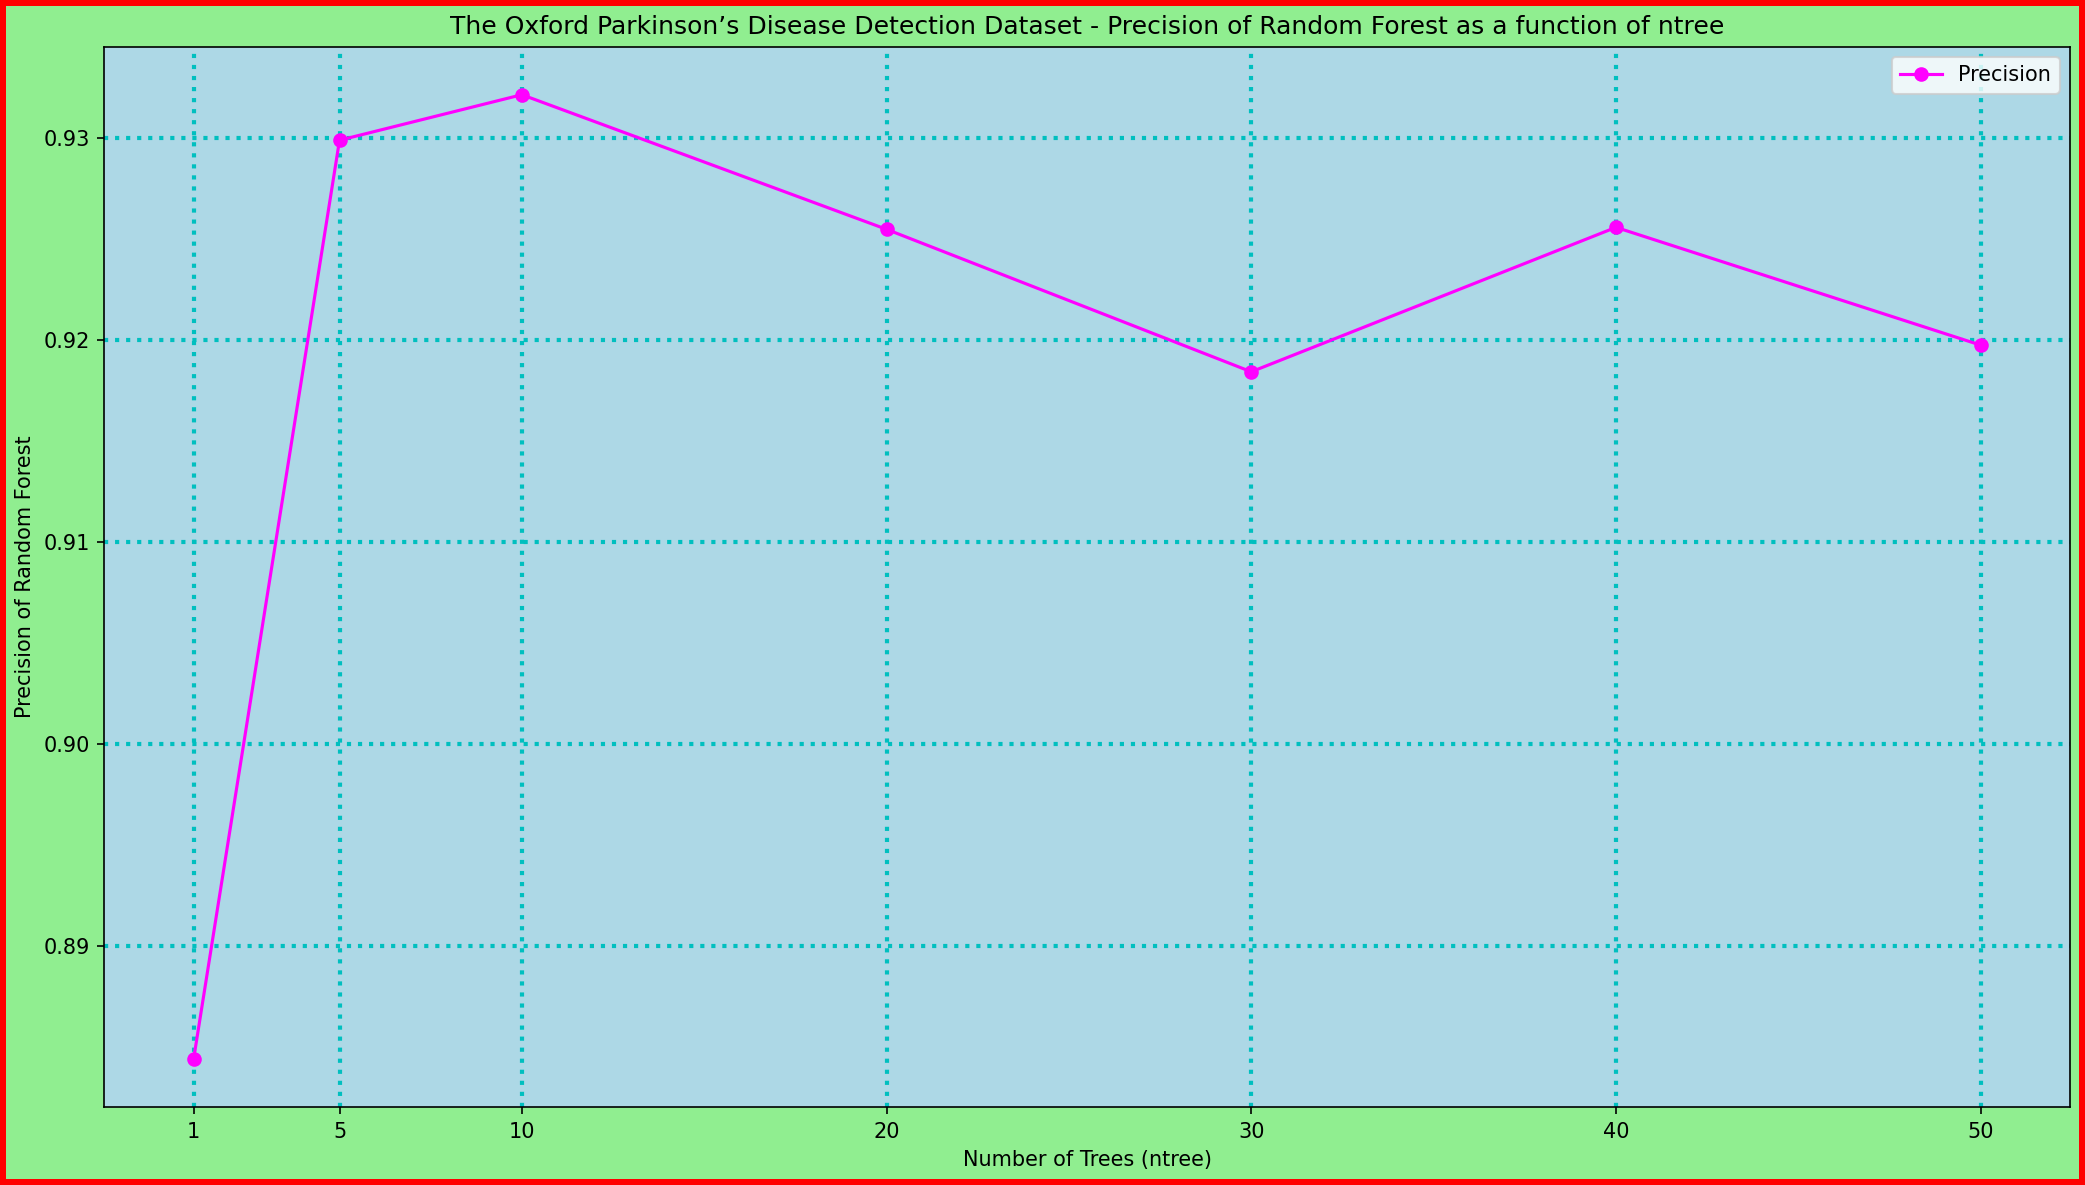

In [265]:
#### Final Project - Mohan Kumar Paramasivan - Dataset 2 ####
#### The Oxford Parkinson’s Disease Detection Dataset ####
#### Algorithm 3 - Random Forest ####

#### Plot 2 - Parkinsons Precision ####
plt.figure(figsize=(14,8), dpi=150.0, facecolor='lightgreen', edgecolor='red', linewidth=5.0, frameon=True, layout='tight')
plt.plot(ntree_values, Parkinsons_precision, marker='o', color='magenta', label='Precision')
plt.xticks(ntree_values)
plt.xlabel('Number of Trees (ntree)')
plt.ylabel('Precision of Random Forest')
plt.title('The Oxford Parkinson’s Disease Detection Dataset - Precision of Random Forest as a function of ntree')
plt.grid(True, axis='both', color='c', linestyle=':', linewidth=2.0, alpha=1.0)
plt.legend()
plt.gca().set_facecolor('lightblue')
plt.savefig('Parkinsons_Precision.pdf')
plt.show()

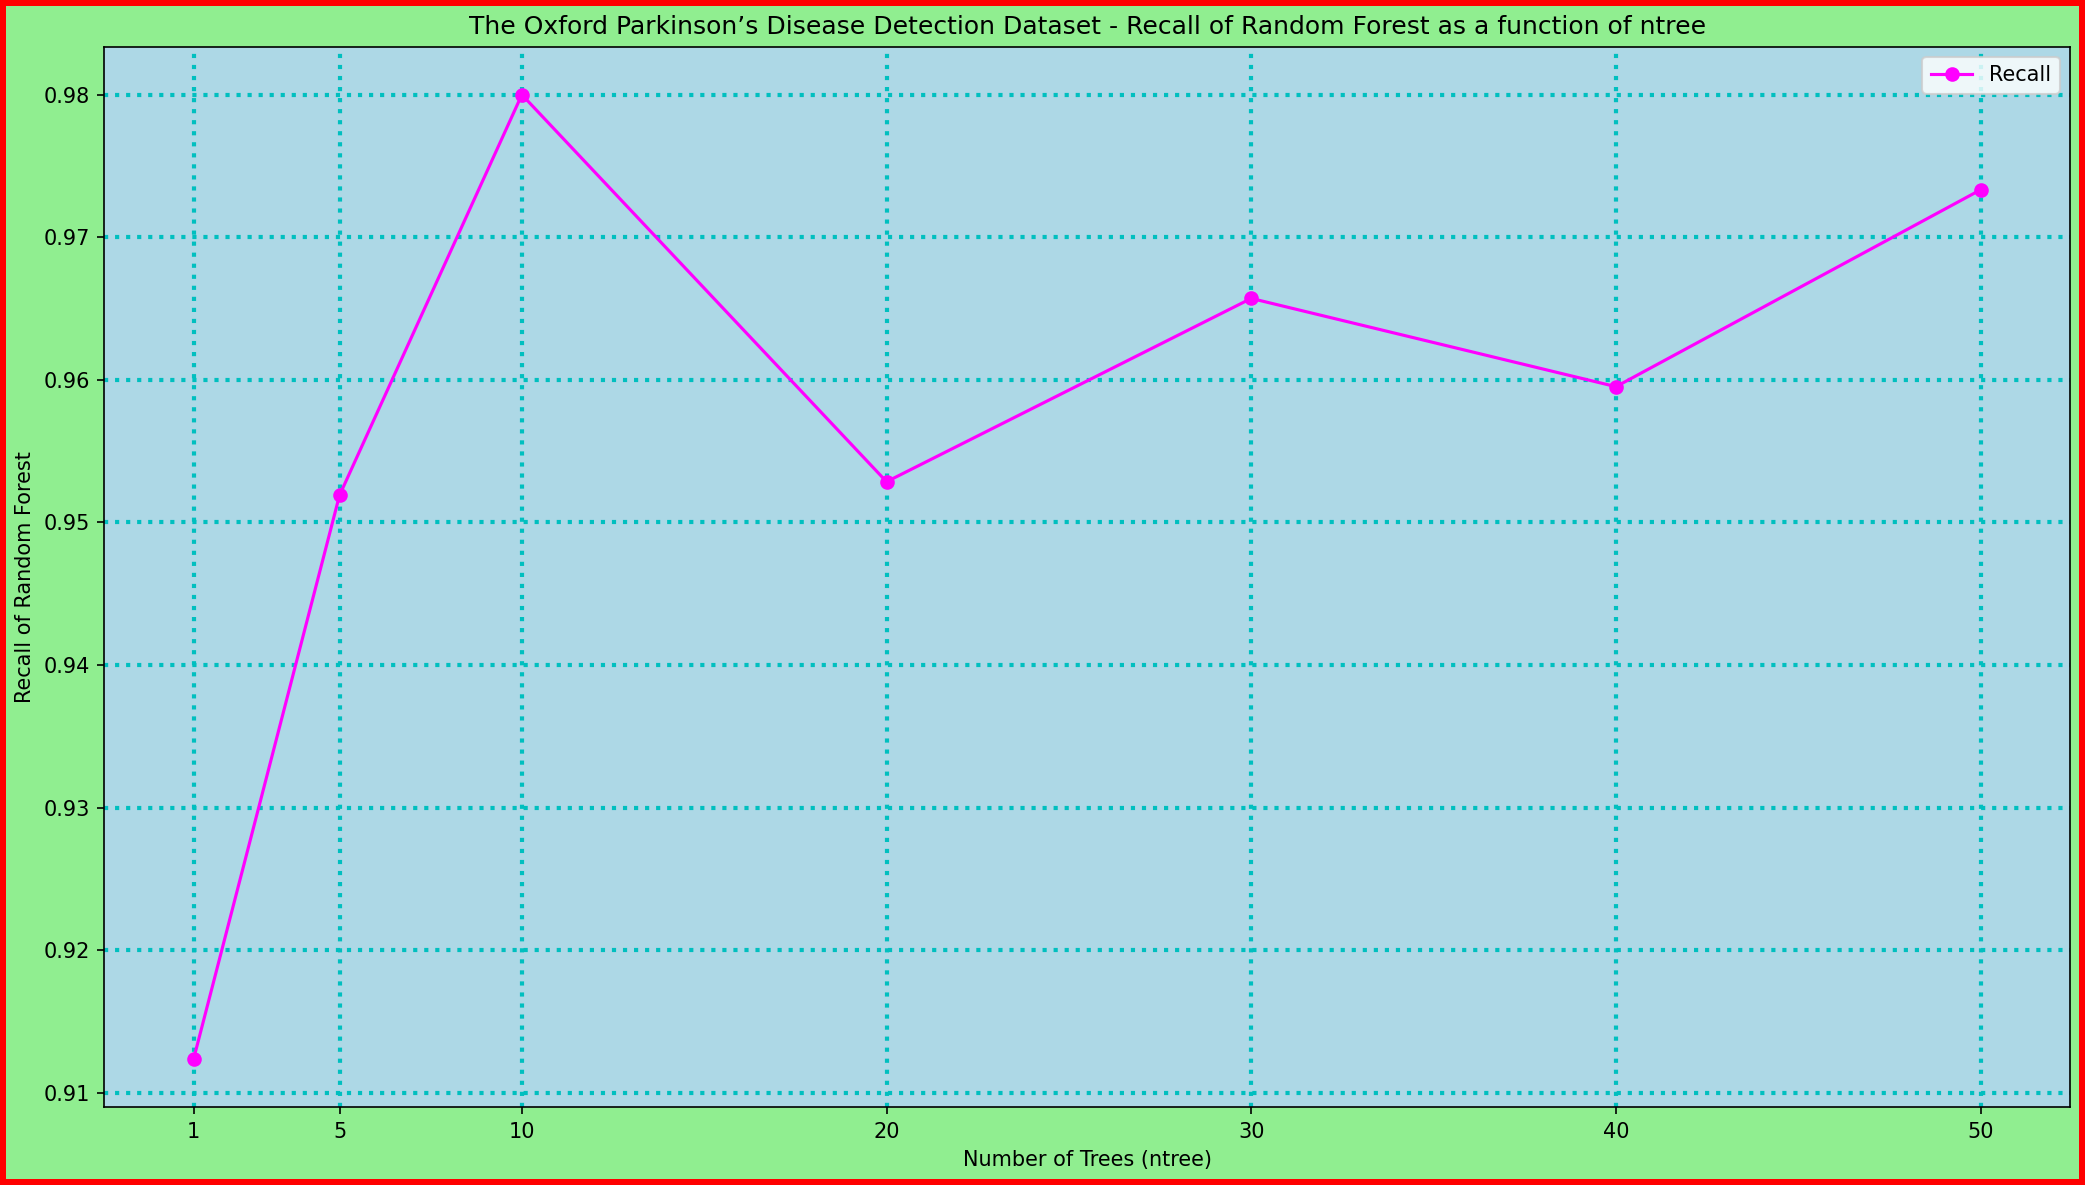

In [267]:
#### Final Project - Mohan Kumar Paramasivan - Dataset 2 ####
#### The Oxford Parkinson’s Disease Detection Dataset ####
#### Algorithm 3 - Random Forest ####

#### Plot 3 - Parkinsons Recall ####
plt.figure(figsize=(14,8), dpi=150.0, facecolor='lightgreen', edgecolor='red', linewidth=5.0, frameon=True, layout='tight')
plt.plot(ntree_values, Parkinsons_recall, marker='o', color='magenta', label='Recall')
plt.xticks(ntree_values)
plt.xlabel('Number of Trees (ntree)')
plt.ylabel('Recall of Random Forest')
plt.title('The Oxford Parkinson’s Disease Detection Dataset - Recall of Random Forest as a function of ntree')
plt.grid(True, axis='both', color='c', linestyle=':', linewidth=2.0, alpha=1.0)
plt.legend()
plt.gca().set_facecolor('lightblue')
plt.savefig('Parkinsons_Recall.pdf')
plt.show()

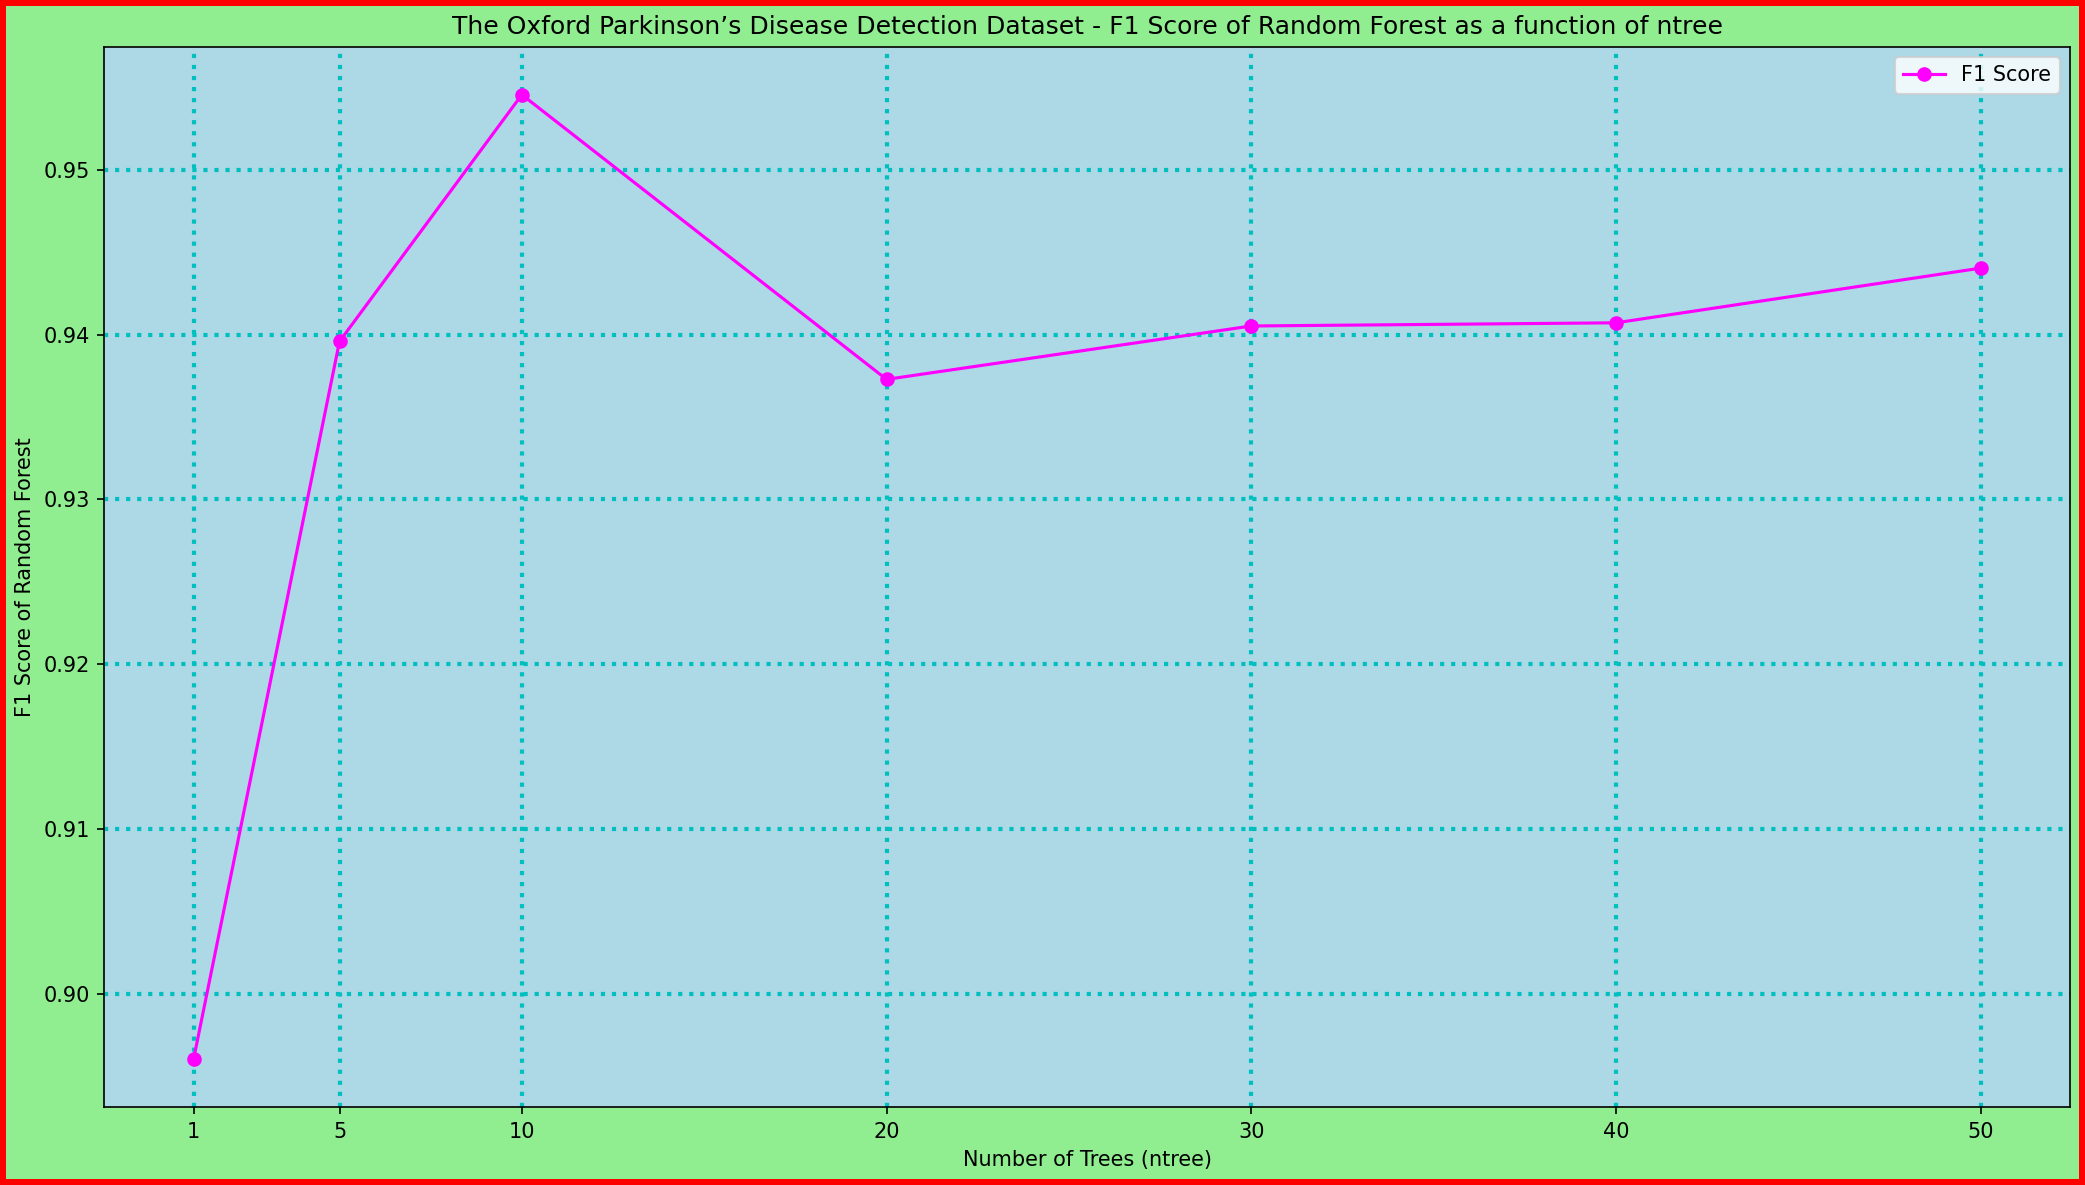

In [269]:
#### Final Project - Mohan Kumar Paramasivan - Dataset 2 ####
#### The Oxford Parkinson’s Disease Detection Dataset ####
#### Algorithm 3 - Random Forest ####

#### Plot 4 - Parkinsons F1 ####
plt.figure(figsize=(14,8), dpi=150.0, facecolor='lightgreen', edgecolor='red', linewidth=5.0, frameon=True, layout='tight')
plt.plot(ntree_values, Parkinsons_f1, marker='o', color='magenta', label='F1 Score')
plt.xticks(ntree_values)
plt.xlabel('Number of Trees (ntree)')
plt.ylabel('F1 Score of Random Forest')
plt.title('The Oxford Parkinson’s Disease Detection Dataset - F1 Score of Random Forest as a function of ntree')
plt.grid(True, axis='both', color='c', linestyle=':', linewidth=2.0, alpha=1.0)
plt.legend()
plt.gca().set_facecolor('lightblue')
plt.savefig('Parkinsons_F1Score.pdf')
plt.show()